<a href="https://colab.research.google.com/github/JSEFERINO/Analisis-de-Datos-con-Python-2020/blob/master/Lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio 10**
# **Estadistica Inferencial**
## **Luis Felipe Patron De Avila**
> Email: patronl@utb.edu.co

> Celular: 3017581955

> Código Estudiantil: T00067960

# **Librerias para Trabar en R**

In [ ]:
# @title **Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

<a name="inicio"></a>


## **1.** [Contexto 1: Brecha salarial por género en el sector financiero](#T1)
## **2.** [Contexto 2: Evaluación de impacto de programa social](#T2)

## **3.** [Contexto 3: Comparación de metodologías educativas](#T3)

## **4.** [Contexto 4: Efecto de una campaña de salud pública](#T4)

## **5.** [Contexto 5: Intención de voto en dos ciudades](#T5)

## **6.** [Contexto 6: Control de calidad en producción agrícola](#T6)

## **7.** [Contexto 7: Comparación de volatilidad en mercados financieros](#T7)


## **8.** [H](#T8)

## **9.** [I](#T9)


## **10.** [J](#T10)

## **11.** [](#T11)

## **12.** [](#T12)

## **13.** [](#T13)

## **14.** [](#T14)

## **15.** [](#T15)

## **16.** [](#T16)

## **17.** [](#T17)


## **18.** [](#T18)

## **19.** [](#T19)


## **20.** [](#T20)

## **21.** [](#T21)

## **22.** [](#T22)

## **23.** [](#T23)

## **24.** [](#T24)

## **25.** [](#T25)

## **26.** [](#T26)

## **27.** [](#T27)


## **28.** [](#T28)

## **29.** [](#T29)


## **30.** [](#T30)

## **31.** [](#T31)



[ULTIMO](#ULTIMO)

[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **1. Contexto 1: Brecha salarial por género en el sector financiero**


## **Pregunta 1**

#**Codigo Python**

=== RESULTADOS ===
Diferencia de medias muestral: 0.6000
Error estándar: 0.1329
Valor z crítico: 1.9600
Margen de error: 0.2605
IC 95.0%: (0.3395, 0.8605)


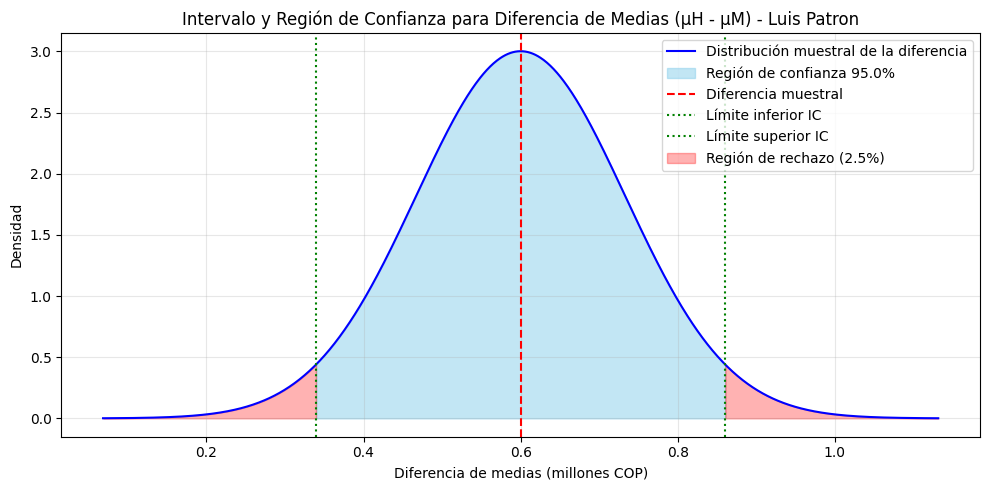

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================
# DATOS
# ============================
mean_h = 4.8   # media hombres
mean_m = 4.2   # media mujeres
std_h = 1.2    # desviación hombres
std_m = 1.1    # desviación mujeres
n_h = 150
n_m = 150
confianza = 0.95

# ============================
# CÁLCULO DEL IC
# ============================
diff_means = mean_h - mean_m

# Error estándar de la diferencia
se_diff = np.sqrt(std_h**2 / n_h + std_m**2 / n_m)

# Valor z crítico
z_crit = stats.norm.ppf(1 - (1 - confianza) / 2)

# Margen de error
margen_error = z_crit * se_diff

# Intervalo de confianza
ic_inferior = diff_means - margen_error
ic_superior = diff_means + margen_error

print("=== RESULTADOS ===")
print(f"Diferencia de medias muestral: {diff_means:.4f}")
print(f"Error estándar: {se_diff:.4f}")
print(f"Valor z crítico: {z_crit:.4f}")
print(f"Margen de error: {margen_error:.4f}")
print(f"IC {confianza*100}%: ({ic_inferior:.4f}, {ic_superior:.4f})")

# ============================
# GRÁFICO: REGIÓN DE CONFIANZA
# ============================
# Distribución muestral de la diferencia
x = np.linspace(diff_means - 4*se_diff, diff_means + 4*se_diff, 1000)
y = stats.norm.pdf(x, diff_means, se_diff)

plt.figure(figsize=(10, 5))
plt.plot(x, y, 'b-', label='Distribución muestral de la diferencia')

# Rellenar región de confianza (zona de no rechazo)
x_ic = np.linspace(ic_inferior, ic_superior, 1000)
y_ic = stats.norm.pdf(x_ic, diff_means, se_diff)
plt.fill_between(x_ic, y_ic, color='skyblue', alpha=0.5, label=f'Región de confianza {confianza*100}%')

# Líneas verticales
plt.axvline(diff_means, color='red', linestyle='--', label='Diferencia muestral')
plt.axvline(ic_inferior, color='green', linestyle=':', label='Límite inferior IC')
plt.axvline(ic_superior, color='green', linestyle=':', label='Límite superior IC')

# Regiones de rechazo (colas)
x_cola_inf = np.linspace(x[0], ic_inferior, 500)
y_cola_inf = stats.norm.pdf(x_cola_inf, diff_means, se_diff)
plt.fill_between(x_cola_inf, y_cola_inf, color='red', alpha=0.3, label='Región de rechazo (2.5%)')

x_cola_sup = np.linspace(ic_superior, x[-1], 500)
y_cola_sup = stats.norm.pdf(x_cola_sup, diff_means, se_diff)
plt.fill_between(x_cola_sup, y_cola_sup, color='red', alpha=0.3)

plt.title('Intervalo y Región de Confianza para Diferencia de Medias (μH - μM) - Luis Patron')
plt.xlabel('Diferencia de medias (millones COP)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#**Codigo R**

=== RESULTADOS ===
Diferencia de medias muestral: 0.6000
Error estándar: 0.1329
Valor z crítico: 1.9600
Margen de error: 0.2605
IC 95%: (0.3395, 0.8605)


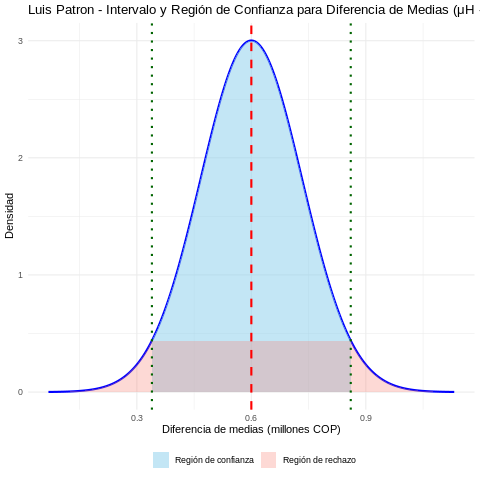

In [ ]:
# ============================
# DATOS
# ============================
%%R
mean_h <- 4.8
mean_m <- 4.2
sd_h <- 1.2
sd_m <- 1.1
n_h <- 150
n_m <- 150
confianza <- 0.95

# ============================
# CÁLCULO DEL IC
# ============================
diff_means <- mean_h - mean_m

# Error estándar de la diferencia
se_diff <- sqrt(sd_h^2 / n_h + sd_m^2 / n_m)

# Valor z crítico
z_crit <- qnorm(1 - (1 - confianza) / 2)

# Margen de error
margen_error <- z_crit * se_diff

# Intervalo de confianza
ic_inferior <- diff_means - margen_error
ic_superior <- diff_means + margen_error

cat("=== RESULTADOS ===\n")
cat(sprintf("Diferencia de medias muestral: %.4f\n", diff_means))
cat(sprintf("Error estándar: %.4f\n", se_diff))
cat(sprintf("Valor z crítico: %.4f\n", z_crit))
cat(sprintf("Margen de error: %.4f\n", margen_error))
cat(sprintf("IC %d%%: (%.4f, %.4f)\n", confianza*100, ic_inferior, ic_superior))

# ============================
# GRÁFICO: REGIÓN DE CONFIANZA
# ============================
library(ggplot2)

# Crear secuencia de valores para la curva normal
x <- seq(diff_means - 4*se_diff, diff_means + 4*se_diff, length.out = 1000)
y <- dnorm(x, mean = diff_means, sd = se_diff)

df <- data.frame(x = x, y = y)

# Identificar región de confianza
df$region <- ifelse(x >= ic_inferior & x <= ic_superior,
                    "Región de confianza",
                    "Región de rechazo")

ggplot(df, aes(x = x, y = y)) +
  geom_line(color = "blue", size = 1) +
  geom_area(data = subset(df, region == "Región de confianza"),
            aes(fill = region), alpha = 0.5) +
  geom_area(data = subset(df, region == "Región de rechazo"),
            aes(fill = region), alpha = 0.3) +
  geom_vline(xintercept = diff_means, color = "red", linetype = "dashed", size = 1) +
  geom_vline(xintercept = ic_inferior, color = "darkgreen", linetype = "dotted", size = 1) +
  geom_vline(xintercept = ic_superior, color = "darkgreen", linetype = "dotted", size = 1) +
  scale_fill_manual(values = c("Región de confianza" = "skyblue",
                               "Región de rechazo" = "salmon")) +
  labs(title = "Luis Patron - Intervalo y Región de Confianza para Diferencia de Medias (μH - μM)",
       x = "Diferencia de medias (millones COP)",
       y = "Densidad",
       fill = "") +
  theme_minimal() +
  theme(legend.position = "bottom")

[⬆️ Volver al inicio](#inicio)

<a name="T2"></a>
## **2. Contexto 2: Evaluación de impacto de programa social**


## **Pregunta 3**

#**Codigo Python**

=== RESULTADOS - Luis Patron ===
Diferencia de medias muestral: 70.00 miles COP
Error estándar: 17.7518
Valor z crítico (99%): 2.5758
Margen de error: 45.73
IC 99.0%: (24.27, 115.73) miles COP

Formato solicitado: 70 ± 45.7


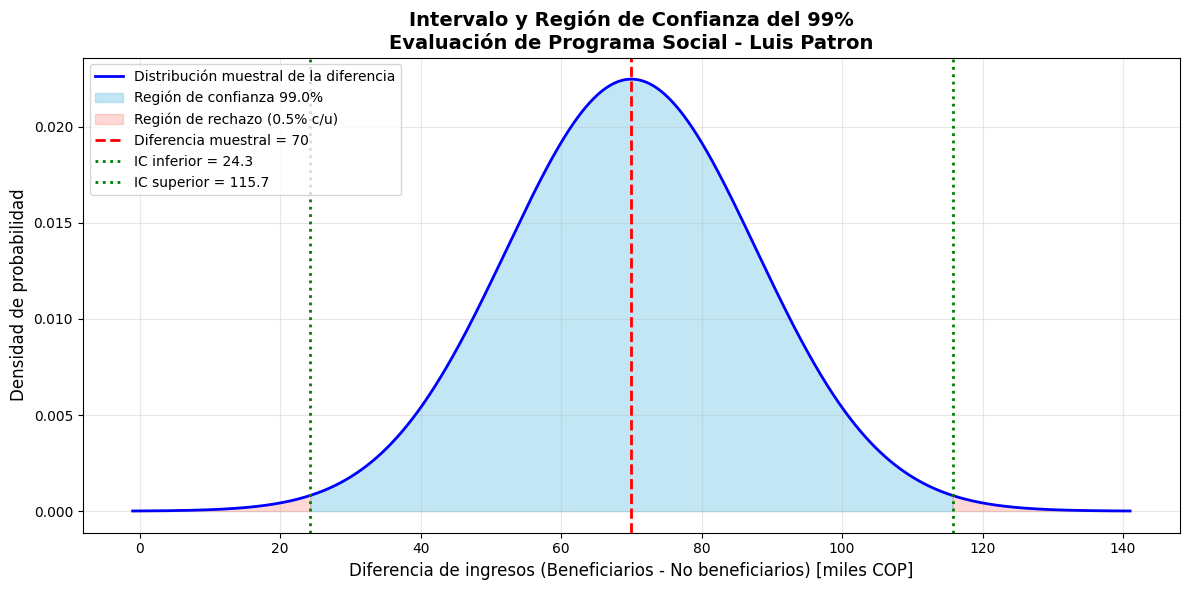

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================
# DATOS
# ============================
media_B = 850      # beneficiarios
media_NB = 780     # no beneficiarios
sd_B = 180
sd_NB = 175
n_B = 200
n_NB = 200
confianza = 0.99
nombre = "Luis Patron"

# ============================
# CÁLCULO DEL IC
# ============================
diff_means = media_B - media_NB

# Error estándar de la diferencia
se_diff = np.sqrt(sd_B**2 / n_B + sd_NB**2 / n_NB)

# Valor z crítico para 99%
z_crit = stats.norm.ppf(1 - (1 - confianza) / 2)

# Margen de error
margen_error = z_crit * se_diff

# Intervalo de confianza
ic_inferior = diff_means - margen_error
ic_superior = diff_means + margen_error

print("=== RESULTADOS - Luis Patron ===")
print(f"Diferencia de medias muestral: {diff_means:.2f} miles COP")
print(f"Error estándar: {se_diff:.4f}")
print(f"Valor z crítico (99%): {z_crit:.4f}")
print(f"Margen de error: {margen_error:.2f}")
print(f"IC {confianza*100}%: ({ic_inferior:.2f}, {ic_superior:.2f}) miles COP")
print(f"\nFormato solicitado: {diff_means:.0f} ± {margen_error:.1f}")

# ============================
# GRÁFICO CON NOMBRE
# ============================
x = np.linspace(diff_means - 4*se_diff, diff_means + 4*se_diff, 1000)
y = stats.norm.pdf(x, diff_means, se_diff)

plt.figure(figsize=(12, 6))
plt.plot(x, y, 'b-', linewidth=2, label='Distribución muestral de la diferencia')

# Rellenar región de confianza
x_ic = np.linspace(ic_inferior, ic_superior, 1000)
y_ic = stats.norm.pdf(x_ic, diff_means, se_diff)
plt.fill_between(x_ic, y_ic, color='skyblue', alpha=0.5, label=f'Región de confianza {confianza*100}%')

# Regiones de rechazo (colas)
x_cola_inf = np.linspace(x[0], ic_inferior, 500)
y_cola_inf = stats.norm.pdf(x_cola_inf, diff_means, se_diff)
plt.fill_between(x_cola_inf, y_cola_inf, color='salmon', alpha=0.3, label='Región de rechazo (0.5% c/u)')

x_cola_sup = np.linspace(ic_superior, x[-1], 500)
y_cola_sup = stats.norm.pdf(x_cola_sup, diff_means, se_diff)
plt.fill_between(x_cola_sup, y_cola_sup, color='salmon', alpha=0.3)

# Líneas verticales
plt.axvline(diff_means, color='red', linestyle='--', linewidth=2, label=f'Diferencia muestral = {diff_means}')
plt.axvline(ic_inferior, color='green', linestyle=':', linewidth=2, label=f'IC inferior = {ic_inferior:.1f}')
plt.axvline(ic_superior, color='green', linestyle=':', linewidth=2, label=f'IC superior = {ic_superior:.1f}')

# Título con nombre
plt.title(f'Intervalo y Región de Confianza del 99%\nEvaluación de Programa Social - Luis Patron', fontsize=14, fontweight='bold')
plt.xlabel('Diferencia de ingresos (Beneficiarios - No beneficiarios) [miles COP]', fontsize=12)
plt.ylabel('Densidad de probabilidad', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#**Codigo R**

=== RESULTADOS - Luis Patron ===
Diferencia de medias muestral: 70.00 miles COP
Error estándar: 17.7518
Valor z crítico (99%): 2.5758
Margen de error: 45.73
IC 99%: (24.27, 115.73) miles COP

Formato solicitado: 70 ± 45.7


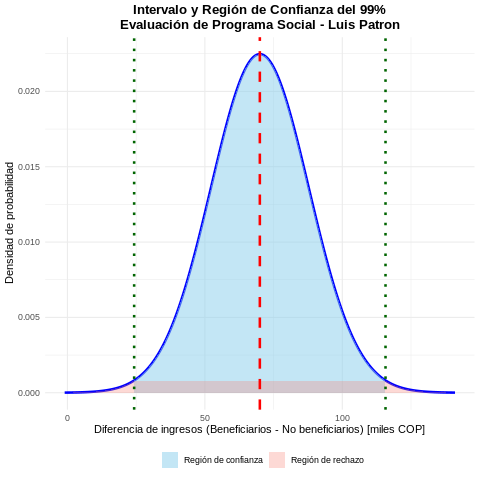

In [ ]:
# ============================
# DATOS
# ============================
%%R
media_B <- 850
media_NB <- 780
sd_B <- 180
sd_NB <- 175
n_B <- 200
n_NB <- 200
confianza <- 0.99
nombre <- "Luis Patron"

# ============================
# CÁLCULO DEL IC
# ============================
diff_means <- media_B - media_NB

# Error estándar
se_diff <- sqrt(sd_B^2 / n_B + sd_NB^2 / n_NB)

# Valor z crítico
z_crit <- qnorm(1 - (1 - confianza) / 2)

# Margen de error
margen_error <- z_crit * se_diff

# Intervalo de confianza
ic_inferior <- diff_means - margen_error
ic_superior <- diff_means + margen_error

cat("=== RESULTADOS -", nombre, "===\n")
cat(sprintf("Diferencia de medias muestral: %.2f miles COP\n", diff_means))
cat(sprintf("Error estándar: %.4f\n", se_diff))
cat(sprintf("Valor z crítico (99%%): %.4f\n", z_crit))
cat(sprintf("Margen de error: %.2f\n", margen_error))
cat(sprintf("IC %d%%: (%.2f, %.2f) miles COP\n", confianza*100, ic_inferior, ic_superior))
cat(sprintf("\nFormato solicitado: %.0f ± %.1f\n", diff_means, margen_error))

# ============================
# GRÁFICO CON NOMBRE
# ============================
library(ggplot2)

x <- seq(diff_means - 4*se_diff, diff_means + 4*se_diff, length.out = 1000)
y <- dnorm(x, mean = diff_means, sd = se_diff)

df <- data.frame(x = x, y = y)

df$region <- ifelse(x >= ic_inferior & x <= ic_superior,
                    "Región de confianza",
                    "Región de rechazo")

ggplot(df, aes(x = x, y = y)) +
  geom_line(color = "blue", size = 1.2) +
  geom_area(data = subset(df, region == "Región de confianza"),
            aes(fill = region), alpha = 0.5) +
  geom_area(data = subset(df, region == "Región de rechazo"),
            aes(fill = region), alpha = 0.3) +
  geom_vline(xintercept = diff_means, color = "red", linetype = "dashed", size = 1.2) +
  geom_vline(xintercept = ic_inferior, color = "darkgreen", linetype = "dotted", size = 1.2) +
  geom_vline(xintercept = ic_superior, color = "darkgreen", linetype = "dotted", size = 1.2) +
  scale_fill_manual(values = c("Región de confianza" = "skyblue",
                               "Región de rechazo" = "salmon")) +
  labs(title = paste("Intervalo y Región de Confianza del 99%\nEvaluación de Programa Social -", nombre),
       x = "Diferencia de ingresos (Beneficiarios - No beneficiarios) [miles COP]",
       y = "Densidad de probabilidad",
       fill = "") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"),
        legend.position = "bottom")

[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## **3. Contexto 3: Comparación de metodologías educativas**


## **Pregunta 5**

#**Codigo Python**

=== RESULTADOS - Luis Patron ===
Diferencia de medias (Trad - Inn): -0.5000
Varianza agrupada: 0.3105
Error estándar: 0.2386
Grados de libertad: 20
Valor t crítico (90%): 1.7247
Margen de error: 0.4115
IC 90%: (-0.9115, -0.0885)

✅ Respuesta pregunta 5: t_0.05, 20 = 1.725


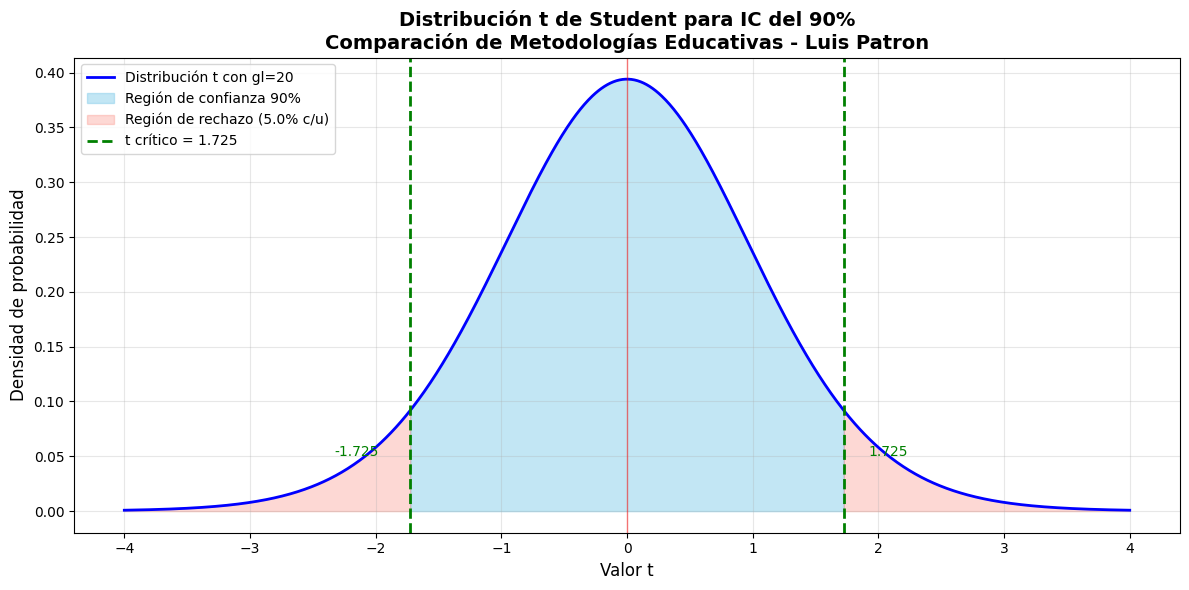

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================
# DATOS
# ============================
media_trad = 3.8
media_inno = 4.3
sd_trad = 0.6
sd_inno = 0.5
n_trad = 12
n_inno = 10
confianza = 0.90
nombre = "Luis Patron"

# ============================
# CÁLCULO DEL IC (varianzas agrupadas)
# ============================
diff_means = media_trad - media_inno

# Varianza agrupada
var_p = ((n_trad - 1) * sd_trad**2 + (n_inno - 1) * sd_inno**2) / (n_trad + n_inno - 2)
sd_p = np.sqrt(var_p)

# Error estándar
se_diff = sd_p * np.sqrt(1/n_trad + 1/n_inno)

# Grados de libertad
gl = n_trad + n_inno - 2

# Valor t crítico
t_crit = stats.t.ppf(1 - (1 - confianza)/2, df=gl)

# Margen de error
margen_error = t_crit * se_diff

# Intervalo de confianza
ic_inferior = diff_means - margen_error
ic_superior = diff_means + margen_error

print("=== RESULTADOS -", nombre, "===")
print(f"Diferencia de medias (Trad - Inn): {diff_means:.4f}")
print(f"Varianza agrupada: {var_p:.4f}")
print(f"Error estándar: {se_diff:.4f}")
print(f"Grados de libertad: {gl}")
print(f"Valor t crítico ({confianza*100:.0f}%): {t_crit:.4f}")
print(f"Margen de error: {margen_error:.4f}")
print(f"IC {confianza*100:.0f}%: ({ic_inferior:.4f}, {ic_superior:.4f})")
print(f"\n✅ Respuesta pregunta 5: t_{0.05:.2f}, {gl} = {t_crit:.3f}")

# ============================
# GRÁFICO CON NOMBRE
# ============================
# Distribución t de Student
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df=gl)

# Valores críticos
t_inferior = stats.t.ppf((1-confianza)/2, df=gl)
t_superior = stats.t.ppf(1 - (1-confianza)/2, df=gl)

plt.figure(figsize=(12, 6))
plt.plot(x, y, 'b-', linewidth=2, label=f'Distribución t con gl={gl}')

# Rellenar región de confianza
x_ic = np.linspace(t_inferior, t_superior, 1000)
y_ic = stats.t.pdf(x_ic, df=gl)
plt.fill_between(x_ic, y_ic, color='skyblue', alpha=0.5, label=f'Región de confianza {confianza*100:.0f}%')

# Regiones de rechazo
x_cola_inf = np.linspace(x[0], t_inferior, 500)
y_cola_inf = stats.t.pdf(x_cola_inf, df=gl)
plt.fill_between(x_cola_inf, y_cola_inf, color='salmon', alpha=0.3, label=f'Región de rechazo ({(1-confianza)/2*100:.1f}% c/u)')

x_cola_sup = np.linspace(t_superior, x[-1], 500)
y_cola_sup = stats.t.pdf(x_cola_sup, df=gl)
plt.fill_between(x_cola_sup, y_cola_sup, color='salmon', alpha=0.3)

# Líneas verticales
plt.axvline(t_crit, color='green', linestyle='--', linewidth=2, label=f't crítico = {t_crit:.3f}')
plt.axvline(-t_crit, color='green', linestyle='--', linewidth=2)
plt.axvline(0, color='red', linestyle='-', linewidth=1, alpha=0.5)

# Título con nombre
plt.title(f'Distribución t de Student para IC del {confianza*100:.0f}%\nComparación de Metodologías Educativas - {nombre}',
          fontsize=14, fontweight='bold')
plt.xlabel('Valor t', fontsize=12)
plt.ylabel('Densidad de probabilidad', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=0.3)
plt.text(t_crit + 0.2, 0.05, f'{t_crit:.3f}', fontsize=10, color='green')
plt.text(-t_crit - 0.6, 0.05, f'{-t_crit:.3f}', fontsize=10, color='green')
plt.tight_layout()
plt.show()

#**Codigo R**

=== RESULTADOS - Luis Patron ===
Diferencia de medias (Trad - Inn): -0.5000
Varianza agrupada: 0.3105
Error estándar: 0.2386
Grados de libertad: 20
Valor t crítico (90%): 1.7247
Margen de error: 0.4115
IC 90%: (-0.9115, -0.0885)

✅ Respuesta pregunta 5: t_{0.05, 20} = 1.725


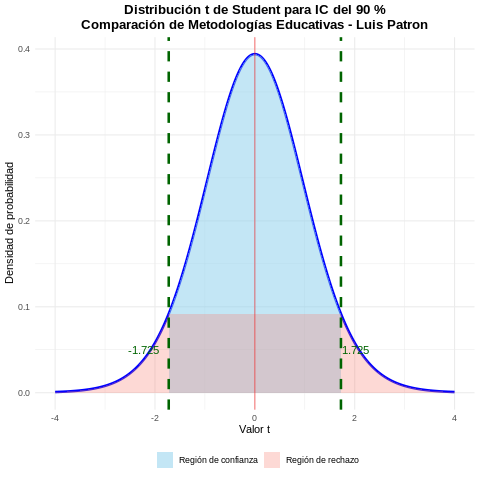

In [ ]:
# ============================
# DATOS
# ============================
%%R
media_trad <- 3.8
media_inno <- 4.3
sd_trad <- 0.6
sd_inno <- 0.5
n_trad <- 12
n_inno <- 10
confianza <- 0.90
nombre <- "Luis Patron"

# ============================
# CÁLCULO DEL IC (varianzas agrupadas)
# ============================
diff_means <- media_trad - media_inno

# Varianza agrupada
var_p <- ((n_trad - 1) * sd_trad^2 + (n_inno - 1) * sd_inno^2) / (n_trad + n_inno - 2)
sd_p <- sqrt(var_p)

# Error estándar
se_diff <- sd_p * sqrt(1/n_trad + 1/n_inno)

# Grados de libertad
gl <- n_trad + n_inno - 2

# Valor t crítico
t_crit <- qt(1 - (1 - confianza)/2, df = gl)

# Margen de error
margen_error <- t_crit * se_diff

# Intervalo de confianza
ic_inferior <- diff_means - margen_error
ic_superior <- diff_means + margen_error

cat("=== RESULTADOS -", nombre, "===\n")
cat(sprintf("Diferencia de medias (Trad - Inn): %.4f\n", diff_means))
cat(sprintf("Varianza agrupada: %.4f\n", var_p))
cat(sprintf("Error estándar: %.4f\n", se_diff))
cat(sprintf("Grados de libertad: %d\n", gl))
cat(sprintf("Valor t crítico (%d%%): %.4f\n", confianza*100, t_crit))
cat(sprintf("Margen de error: %.4f\n", margen_error))
cat(sprintf("IC %d%%: (%.4f, %.4f)\n", confianza*100, ic_inferior, ic_superior))
cat(sprintf("\n✅ Respuesta pregunta 5: t_{0.05, %d} = %.3f\n", gl, t_crit))

# ============================
# GRÁFICO CON NOMBRE
# ============================
library(ggplot2)

x <- seq(-4, 4, length.out = 1000)
y <- dt(x, df = gl)

df_plot <- data.frame(x = x, y = y)

# Valores críticos
t_crit_inf <- qt((1 - confianza)/2, df = gl)
t_crit_sup <- qt(1 - (1 - confianza)/2, df = gl)

df_plot$region <- ifelse(x >= t_crit_inf & x <= t_crit_sup,
                         "Región de confianza",
                         "Región de rechazo")

ggplot(df_plot, aes(x = x, y = y)) +
  geom_line(color = "blue", size = 1.2) +
  geom_area(data = subset(df_plot, region == "Región de confianza"),
            aes(fill = region), alpha = 0.5) +
  geom_area(data = subset(df_plot, region == "Región de rechazo"),
            aes(fill = region), alpha = 0.3) +
  geom_vline(xintercept = t_crit, color = "darkgreen", linetype = "dashed", size = 1.2) +
  geom_vline(xintercept = -t_crit, color = "darkgreen", linetype = "dashed", size = 1.2) +
  geom_vline(xintercept = 0, color = "red", linetype = "solid", size = 0.5, alpha = 0.5) +
  scale_fill_manual(values = c("Región de confianza" = "skyblue",
                               "Región de rechazo" = "salmon")) +
  annotate("text", x = t_crit + 0.3, y = 0.05, label = sprintf("%.3f", t_crit),
           color = "darkgreen", size = 4) +
  annotate("text", x = -t_crit - 0.5, y = 0.05, label = sprintf("%.3f", -t_crit),
           color = "darkgreen", size = 4) +
  labs(title = paste("Distribución t de Student para IC del", confianza*100, "%\nComparación de Metodologías Educativas -", nombre),
       x = "Valor t",
       y = "Densidad de probabilidad",
       fill = "") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"),
        legend.position = "bottom")

## **Pregunta 6**

## **Codigo Python**

=== RESULTADOS - Luis Patron ===
Diferencia de medias (Innovador - Tradicional): 0.5000
Varianza agrupada: 0.3105
Error estándar: 0.2386
Grados de libertad: 20
Valor t crítico (90%): 1.7247
Margen de error: 0.4115
IC 90%: (0.0885, 0.9115)

✅ Respuesta pregunta 6: 0.50 ± 0.41
→ Opción correcta: 0.50 ± 0.41 (aproxima a 0.42)


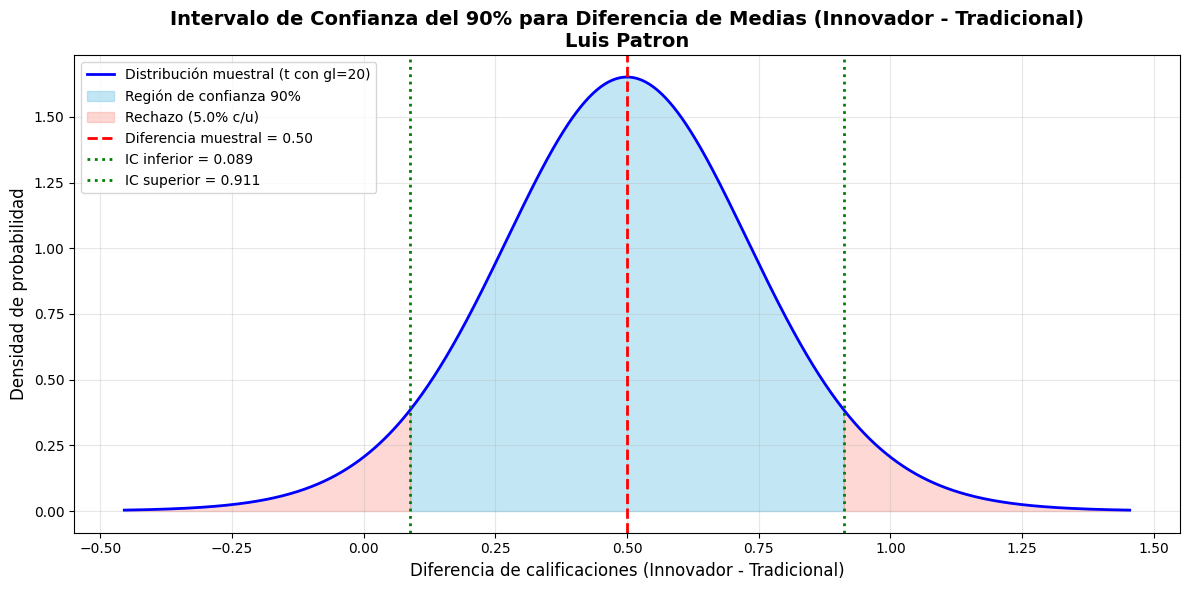

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================
# DATOS
# ============================
media_T = 3.8   # tradicional
media_I = 4.3   # innovador
sd_T = 0.6
sd_I = 0.5
n_T = 12
n_I = 10
confianza = 0.90
nombre = "Luis Patron"

# ============================
# CÁLCULO DEL IC para μI - μT
# ============================
diff_means = media_I - media_T  # Innovador - Tradicional

# Varianza agrupada
var_p = ((n_T - 1) * sd_T**2 + (n_I - 1) * sd_I**2) / (n_T + n_I - 2)
sd_p = np.sqrt(var_p)

# Error estándar
se_diff = sd_p * np.sqrt(1/n_T + 1/n_I)

# Grados de libertad
gl = n_T + n_I - 2

# Valor t crítico
t_crit = stats.t.ppf(1 - (1 - confianza)/2, df=gl)

# Margen de error
margen_error = t_crit * se_diff

# Intervalo de confianza
ic_inferior = diff_means - margen_error
ic_superior = diff_means + margen_error

print("=== RESULTADOS -", nombre, "===")
print(f"Diferencia de medias (Innovador - Tradicional): {diff_means:.4f}")
print(f"Varianza agrupada: {var_p:.4f}")
print(f"Error estándar: {se_diff:.4f}")
print(f"Grados de libertad: {gl}")
print(f"Valor t crítico ({confianza*100:.0f}%): {t_crit:.4f}")
print(f"Margen de error: {margen_error:.4f}")
print(f"IC {confianza*100:.0f}%: ({ic_inferior:.4f}, {ic_superior:.4f})")
print(f"\n✅ Respuesta pregunta 6: {diff_means:.2f} ± {margen_error:.2f}")
print(f"→ Opción correcta: 0.50 ± {margen_error:.2f} (aproxima a 0.42)")

# ============================
# GRÁFICO CON NOMBRE
# ============================
# Distribución t de Student
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df=gl)

# Valores críticos
t_inferior = stats.t.ppf((1-confianza)/2, df=gl)
t_superior = stats.t.ppf(1 - (1-confianza)/2, df=gl)

# Transformar a escala de diferencia de medias
x_diff = diff_means + x * se_diff
y_diff = y / se_diff  # Ajuste de densidad por cambio de variable

plt.figure(figsize=(12, 6))
plt.plot(x_diff, y_diff, 'b-', linewidth=2, label=f'Distribución muestral (t con gl={gl})')

# Rellenar región de confianza
ic_inf_t = (ic_inferior - diff_means) / se_diff
ic_sup_t = (ic_superior - diff_means) / se_diff
x_ic = np.linspace(ic_inferior, ic_superior, 1000)
y_ic = stats.t.pdf((x_ic - diff_means)/se_diff, df=gl) / se_diff
plt.fill_between(x_ic, y_ic, color='skyblue', alpha=0.5, label=f'Región de confianza {confianza*100:.0f}%')

# Regiones de rechazo
x_cola_inf = np.linspace(x_diff[0], ic_inferior, 500)
y_cola_inf = stats.t.pdf((x_cola_inf - diff_means)/se_diff, df=gl) / se_diff
plt.fill_between(x_cola_inf, y_cola_inf, color='salmon', alpha=0.3, label=f'Rechazo ({(1-confianza)/2*100:.1f}% c/u)')

x_cola_sup = np.linspace(ic_superior, x_diff[-1], 500)
y_cola_sup = stats.t.pdf((x_cola_sup - diff_means)/se_diff, df=gl) / se_diff
plt.fill_between(x_cola_sup, y_cola_sup, color='salmon', alpha=0.3)

# Líneas verticales
plt.axvline(diff_means, color='red', linestyle='--', linewidth=2, label=f'Diferencia muestral = {diff_means:.2f}')
plt.axvline(ic_inferior, color='green', linestyle=':', linewidth=2, label=f'IC inferior = {ic_inferior:.3f}')
plt.axvline(ic_superior, color='green', linestyle=':', linewidth=2, label=f'IC superior = {ic_superior:.3f}')

# Título con nombre
plt.title(f'Intervalo de Confianza del {confianza*100:.0f}% para Diferencia de Medias (Innovador - Tradicional)\n{nombre}',
          fontsize=14, fontweight='bold')
plt.xlabel('Diferencia de calificaciones (Innovador - Tradicional)', fontsize=12)
plt.ylabel('Densidad de probabilidad', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **Codigo R**

=== RESULTADOS - Luis Patron ===
Diferencia de medias (Innovador - Tradicional): 0.5000
Varianza agrupada: 0.3105
Error estándar: 0.2386
Grados de libertad: 20
Valor t crítico (90%): 1.7247
Margen de error: 0.4115
IC 90%: (0.0885, 0.9115)

✅ Respuesta pregunta 6: 0.50 ± 0.41
→ Opción correcta: 0.50 ± 0.41 (aproxima a 0.42)


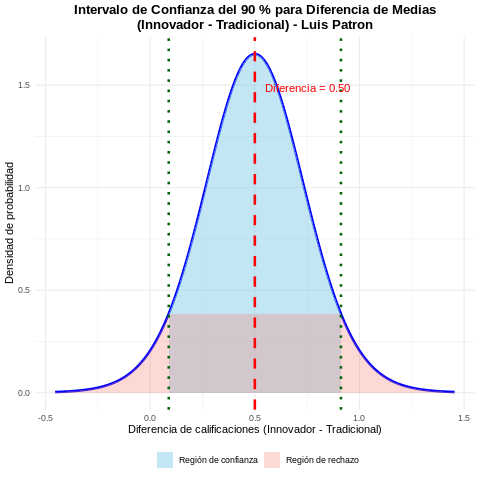

In [ ]:
# ============================
# DATOS
# ============================
%%R
media_T <- 3.8   # tradicional
media_I <- 4.3   # innovador
sd_T <- 0.6
sd_I <- 0.5
n_T <- 12
n_I <- 10
confianza <- 0.90
nombre <- "Luis Patron"

# ============================
# CÁLCULO DEL IC para μI - μT
# ============================
diff_means <- media_I - media_T

# Varianza agrupada
var_p <- ((n_T - 1) * sd_T^2 + (n_I - 1) * sd_I^2) / (n_T + n_I - 2)
sd_p <- sqrt(var_p)

# Error estándar
se_diff <- sd_p * sqrt(1/n_T + 1/n_I)

# Grados de libertad
gl <- n_T + n_I - 2

# Valor t crítico
t_crit <- qt(1 - (1 - confianza)/2, df = gl)

# Margen de error
margen_error <- t_crit * se_diff

# Intervalo de confianza
ic_inferior <- diff_means - margen_error
ic_superior <- diff_means + margen_error

cat("=== RESULTADOS -", nombre, "===\n")
cat(sprintf("Diferencia de medias (Innovador - Tradicional): %.4f\n", diff_means))
cat(sprintf("Varianza agrupada: %.4f\n", var_p))
cat(sprintf("Error estándar: %.4f\n", se_diff))
cat(sprintf("Grados de libertad: %d\n", gl))
cat(sprintf("Valor t crítico (%d%%): %.4f\n", confianza*100, t_crit))
cat(sprintf("Margen de error: %.4f\n", margen_error))
cat(sprintf("IC %d%%: (%.4f, %.4f)\n", confianza*100, ic_inferior, ic_superior))
cat(sprintf("\n✅ Respuesta pregunta 6: %.2f ± %.2f\n", diff_means, margen_error))
cat(sprintf("→ Opción correcta: 0.50 ± %.2f (aproxima a 0.42)\n", margen_error))

# ============================
# GRÁFICO CON NOMBRE
# ============================
library(ggplot2)

# Crear secuencia para la distribución t en escala original
x_t <- seq(-4, 4, length.out = 1000)
y_t <- dt(x_t, df = gl)

# Transformar a escala de diferencia de medias
x_diff <- diff_means + x_t * se_diff
y_diff <- y_t / se_diff

df_plot <- data.frame(x = x_diff, y = y_diff)

# Identificar regiones
df_plot$region <- ifelse(x_diff >= ic_inferior & x_diff <= ic_superior,
                         "Región de confianza",
                         "Región de rechazo")

ggplot(df_plot, aes(x = x, y = y)) +
  geom_line(color = "blue", size = 1.2) +
  geom_area(data = subset(df_plot, region == "Región de confianza"),
            aes(fill = region), alpha = 0.5) +
  geom_area(data = subset(df_plot, region == "Región de rechazo"),
            aes(fill = region), alpha = 0.3) +
  geom_vline(xintercept = diff_means, color = "red", linetype = "dashed", size = 1.2) +
  geom_vline(xintercept = ic_inferior, color = "darkgreen", linetype = "dotted", size = 1.2) +
  geom_vline(xintercept = ic_superior, color = "darkgreen", linetype = "dotted", size = 1.2) +
  scale_fill_manual(values = c("Región de confianza" = "skyblue",
                               "Región de rechazo" = "salmon")) +
  annotate("text", x = diff_means + 0.05, y = max(y_diff) * 0.9,
           label = sprintf("Diferencia = %.2f", diff_means),
           color = "red", size = 4, hjust = 0) +
  labs(title = paste("Intervalo de Confianza del", confianza*100, "% para Diferencia de Medias\n(Innovador - Tradicional) -", nombre),
       x = "Diferencia de calificaciones (Innovador - Tradicional)",
       y = "Densidad de probabilidad",
       fill = "") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"),
        legend.position = "bottom")

## **Pregunta 7**

## **Codigo Python**

=== RESULTADOS - Luis Patron ===
Método tradicional: n1 = 12, s1 = 0.6, var1 = 0.36
Método innovador: n2 = 10, s2 = 0.5, var2 = 0.25
Grados de libertad: 20

✅ Varianza combinada (Sp²) = 0.310500
✅ Redondeado a 3 decimales: 0.310

Desviación combinada (Sp) = 0.5572


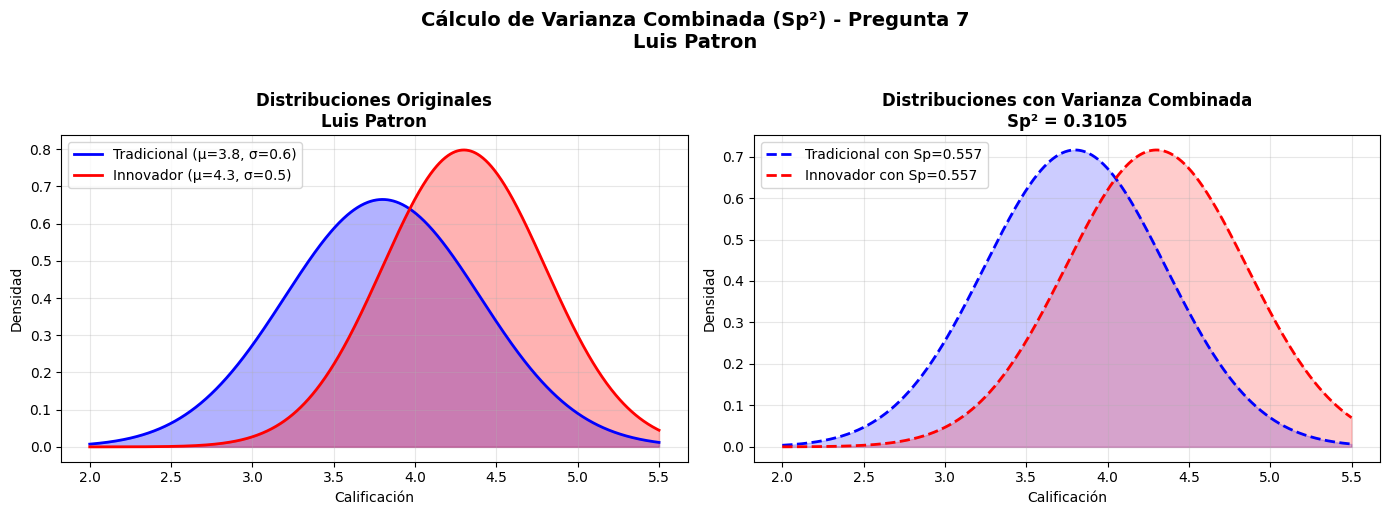

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================
# DATOS
# ============================
n1 = 12  # tradicional
n2 = 10  # innovador
s1 = 0.6  # desviación tradicional
s2 = 0.5  # desviación innovador
nombre = "Luis Patron"

# ============================
# CÁLCULO DE VARIANZA COMBINADA
# ============================
var1 = s1**2
var2 = s2**2

# Fórmula de varianza combinada
sp2 = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)

# Desviación combinada
sp = np.sqrt(sp2)

print("=== RESULTADOS -", nombre, "===")
print(f"Método tradicional: n1 = {n1}, s1 = {s1}, var1 = {var1}")
print(f"Método innovador: n2 = {n2}, s2 = {s2}, var2 = {var2}")
print(f"Grados de libertad: {n1 + n2 - 2}")
print(f"\n✅ Varianza combinada (Sp²) = {sp2:.6f}")
print(f"✅ Redondeado a 3 decimales: {sp2:.3f}")
print(f"\nDesviación combinada (Sp) = {sp:.4f}")

# ============================
# GRÁFICO: COMPARACIÓN DE VARIANZAS
# ============================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribuciones individuales
x = np.linspace(2, 5.5, 1000)
y1 = stats.norm.pdf(x, 3.8, s1)
y2 = stats.norm.pdf(x, 4.3, s2)

ax1.plot(x, y1, 'b-', linewidth=2, label=f'Tradicional (μ=3.8, σ={s1})')
ax1.plot(x, y2, 'r-', linewidth=2, label=f'Innovador (μ=4.3, σ={s2})')
ax1.fill_between(x, y1, alpha=0.3, color='blue')
ax1.fill_between(x, y2, alpha=0.3, color='red')
ax1.set_title(f'Distribuciones Originales\n{nombre}', fontsize=12, fontweight='bold')
ax1.set_xlabel('Calificación')
ax1.set_ylabel('Densidad')
ax1.legend()
ax1.grid(alpha=0.3)

# Gráfico 2: Varianza combinada
x_comb = np.linspace(2, 5.5, 1000)
y_comb_trad = stats.norm.pdf(x_comb, 3.8, sp)
y_comb_inno = stats.norm.pdf(x_comb, 4.3, sp)

ax2.plot(x_comb, y_comb_trad, 'b--', linewidth=2, label=f'Tradicional con Sp={sp:.3f}')
ax2.plot(x_comb, y_comb_inno, 'r--', linewidth=2, label=f'Innovador con Sp={sp:.3f}')
ax2.fill_between(x_comb, y_comb_trad, alpha=0.2, color='blue')
ax2.fill_between(x_comb, y_comb_inno, alpha=0.2, color='red')
ax2.set_title(f'Distribuciones con Varianza Combinada\nSp² = {sp2:.4f}', fontsize=12, fontweight='bold')
ax2.set_xlabel('Calificación')
ax2.set_ylabel('Densidad')
ax2.legend()
ax2.grid(alpha=0.3)

# Texto con el resultado
fig.suptitle(f'Cálculo de Varianza Combinada (Sp²) - Pregunta 7\n{nombre}',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

## **Codigo R**

=== RESULTADOS - Luis Patron ===
Método tradicional: n1 = 12, s1 = 0.6, var1 = 0.360
Método innovador: n2 = 10, s2 = 0.5, var2 = 0.250
Grados de libertad: 20

✅ Varianza combinada (Sp²) = 0.310500
✅ Redondeado a 3 decimales: 0.310

Desviación combinada (Sp) = 0.5572


Loading required package: patchwork
Attempting to install 'patchwork' package...
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘V8’, ‘litedown’, ‘reactR’, ‘rex’, ‘bigD’, ‘bitops’, ‘juicyjuice’, ‘markdown’, ‘reactable’, ‘gridGraphics’, ‘gridExtra’, ‘vdiffr’, ‘covr’, ‘png’, ‘gt’

trying URL 'http://cran.us.r-project.org/src/contrib/V8_8.1.0.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/litedown_0.9.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/reactR_0.6.1.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/rex_1.2.2.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/bigD_0.3.1.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/bitops_1.0-9.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/juicyjuice_0.1.0.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/markdown_2.0.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/reactable_0.

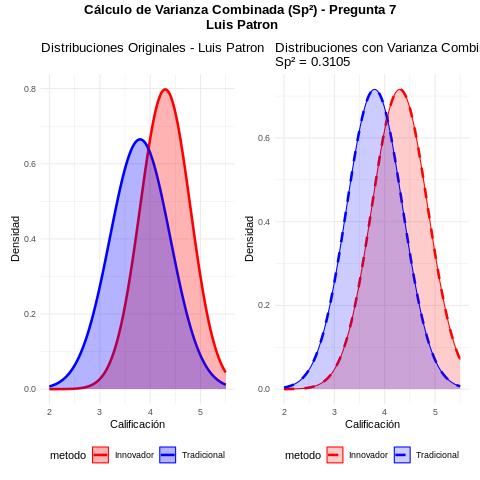

In [ ]:
%%R
n1 <- 12  # tradicional
n2 <- 10  # innovador
s1 <- 0.6  # desviación tradicional
s2 <- 0.5  # desviación innovador
nombre <- "Luis Patron"

# ============================
# CÁLCULO DE VARIANZA COMBINADA
# ============================
var1 <- s1^2
var2 <- s2^2

# Fórmula de varianza combinada
sp2 <- ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)

# Desviación combinada
sp <- sqrt(sp2)

cat("=== RESULTADOS -", nombre, "===\n")
cat(sprintf("Método tradicional: n1 = %d, s1 = %.1f, var1 = %.3f\n", n1, s1, var1))
cat(sprintf("Método innovador: n2 = %d, s2 = %.1f, var2 = %.3f\n", n2, s2, var2))
cat(sprintf("Grados de libertad: %d\n", n1 + n2 - 2))
cat(sprintf("\n✅ Varianza combinada (Sp²) = %.6f\n", sp2))
cat(sprintf("✅ Redondeado a 3 decimales: %.3f\n", sp2))
cat(sprintf("\nDesviación combinada (Sp) = %.4f\n", sp))

# ============================
# GRÁFICO: COMPARACIÓN DE VARIANZAS
# ============================
# Instalar patchwork si no está instalado y cargarlo
if (!require(patchwork)) {
  message("Attempting to install 'patchwork' package...")
  install.packages("patchwork", dependencies = TRUE, repos = "http://cran.us.r-project.org")
  if (require(patchwork)) {
    message("'patchwork' installed and loaded successfully.")
  } else {
    stop("Failed to install and load 'patchwork' package. Please check the error messages above.")
  }
} else {
  message("'patchwork' is already installed and loaded.")
}
library(ggplot2)

# Datos para distribuciones originales
x <- seq(2, 5.5, length.out = 1000)
y_trad_orig <- dnorm(x, mean = 3.8, sd = s1)
y_inno_orig <- dnorm(x, mean = 4.3, sd = s2)

df_orig <- data.frame(
  x = rep(x, 2),
  densidad = c(y_trad_orig, y_inno_orig),
  metodo = rep(c("Tradicional", "Innovador"), each = length(x))
)

# Datos para distribuciones con varianza combinada
y_trad_comb <- dnorm(x, mean = 3.8, sd = sp)
y_inno_comb <- dnorm(x, mean = 4.3, sd = sp)

df_comb <- data.frame(
  x = rep(x, 2),
  densidad = c(y_trad_comb, y_inno_comb),
  metodo = rep(c("Tradicional", "Innovador"), each = length(x))
)

# Gráfico 1: Distribuciones originales
p1 <- ggplot(df_orig, aes(x = x, y = densidad, fill = metodo, color = metodo)) +
  geom_line(size = 1.2) +
  geom_area(alpha = 0.3, position = "identity") +
  scale_fill_manual(values = c("Tradicional" = "blue", "Innovador" = "red")) +
  scale_color_manual(values = c("Tradicional" = "blue", "Innovador" = "red")) +
  labs(title = paste("Distribuciones Originales -", nombre),
       x = "Calificación", y = "Densidad") +
  theme_minimal() +
  theme(legend.position = "bottom")

# Gráfico 2: Distribuciones con varianza combinada
p2 <- ggplot(df_comb, aes(x = x, y = densidad, fill = metodo, color = metodo)) +
  geom_line(size = 1.2, linetype = "dashed") +
  geom_area(alpha = 0.2, position = "identity") +
  scale_fill_manual(values = c("Tradicional" = "blue", "Innovador" = "red")) +
  scale_color_manual(values = c("Tradicional" = "blue", "Innovador" = "red")) +
  labs(title = paste("Distribuciones con Varianza Combinada\nSp² =", round(sp2, 4)),
       x = "Calificación", y = "Densidad") +
  theme_minimal() +
  theme(legend.position = "bottom")

# Combinar gráficos
p1 + p2 + plot_annotation(
  title = paste("Cálculo de Varianza Combinada (Sp²) - Pregunta 7\n", nombre),
  theme = theme(plot.title = element_text(hjust = 0.5, face = "bold"))
)

[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## **4. Contexto 4: Efecto de una campaña de salud pública**


# **Pregunta 8.**

  # **Codigo Python**

=== RESULTADOS - Luis Patron ===
Barrio A (Intervención): n1 = 15
Barrio B (Control): n2 = 13

✅ Grados de libertad (varianzas iguales): gl = n1 + n2 - 2 = 15 + 13 - 2 = 26

→ Opción correcta: A. 26

=== INFORMACIÓN ADICIONAL ===
Diferencia de medias (Intervención - Control): 2.30
Varianza combinada (Sp²): 8.3754
Error estándar: 1.0966
IC 95%: (0.05, 4.55)


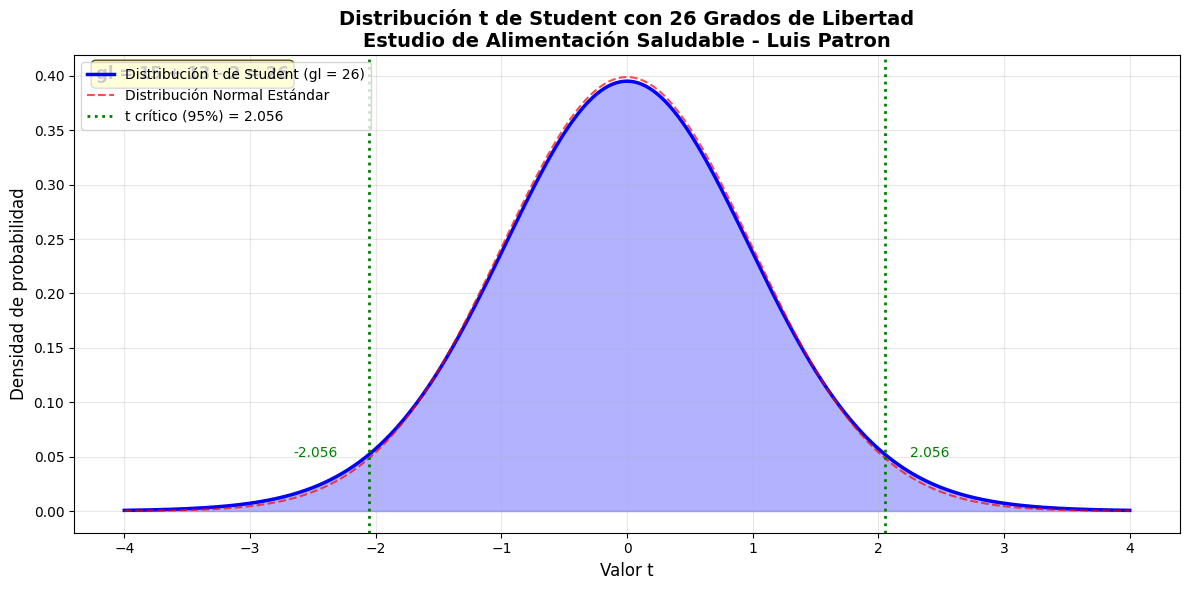

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================
# DATOS
# ============================
n1 = 15  # Barrio A (Intervención)
n2 = 13  # Barrio B (Control)
media1 = 12.5
media2 = 10.2
s1 = 2.8
s2 = 3.0
nombre = "Luis Patron"

# ============================
# CÁLCULO DE GRADOS DE LIBERTAD
# ============================
gl = n1 + n2 - 2

print("=== RESULTADOS -", nombre, "===")
print(f"Barrio A (Intervención): n1 = {n1}")
print(f"Barrio B (Control): n2 = {n2}")
print(f"\n✅ Grados de libertad (varianzas iguales): gl = n1 + n2 - 2 = {n1} + {n2} - 2 = {gl}")
print(f"\n→ Opción correcta: A. {gl}")

# ============================
# CÁLCULO ADICIONAL: IC COMPLETO (opcional)
# ============================
# Varianza combinada
var1 = s1**2
var2 = s2**2
sp2 = ((n1 - 1) * var1 + (n2 - 1) * var2) / gl
sp = np.sqrt(sp2)

# Diferencia de medias
diff_means = media1 - media2

# Error estándar
se_diff = sp * np.sqrt(1/n1 + 1/n2)

# Valor t crítico (95% como ejemplo)
t_crit = stats.t.ppf(0.975, df=gl)

# Margen de error y IC
margen_error = t_crit * se_diff
ic_inferior = diff_means - margen_error
ic_superior = diff_means + margen_error

print(f"\n=== INFORMACIÓN ADICIONAL ===")
print(f"Diferencia de medias (Intervención - Control): {diff_means:.2f}")
print(f"Varianza combinada (Sp²): {sp2:.4f}")
print(f"Error estándar: {se_diff:.4f}")
print(f"IC 95%: ({ic_inferior:.2f}, {ic_superior:.2f})")

# ============================
# GRÁFICO: DISTRIBUCIÓN t CON LOS gl
# ============================
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df=gl)

# Comparar con distribución normal
y_normal = stats.norm.pdf(x, 0, 1)

plt.figure(figsize=(12, 6))
plt.plot(x, y, 'b-', linewidth=2.5, label=f'Distribución t de Student (gl = {gl})')
plt.plot(x, y_normal, 'r--', linewidth=1.5, label='Distribución Normal Estándar', alpha=0.7)
plt.fill_between(x, y, alpha=0.3, color='blue')

# Valores críticos para 95%
t_crit_95 = stats.t.ppf(0.975, df=gl)
plt.axvline(t_crit_95, color='green', linestyle=':', linewidth=2, label=f't crítico (95%) = {t_crit_95:.3f}')
plt.axvline(-t_crit_95, color='green', linestyle=':', linewidth=2)

plt.title(f'Distribución t de Student con {gl} Grados de Libertad\nEstudio de Alimentación Saludable - {nombre}',
          fontsize=14, fontweight='bold')
plt.xlabel('Valor t', fontsize=12)
plt.ylabel('Densidad de probabilidad', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=0.3)
plt.text(t_crit_95 + 0.2, 0.05, f'{t_crit_95:.3f}', fontsize=10, color='green')
plt.text(-t_crit_95 - 0.6, 0.05, f'{-t_crit_95:.3f}', fontsize=10, color='green')

# Anotación con los grados de libertad
plt.annotate(f'gl = {n1} + {n2} - 2 = {gl}',
             xy=(0.02, 0.95), xycoords='axes fraction',
             fontsize=12, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.tight_layout()
plt.show()

  # **Codigo R**

In [ ]:
# ============================
# DATOS
# ============================
%%R
n1 <- 15  # Barrio A (Intervención)
n2 <- 13  # Barrio B (Control)
media1 <- 12.5
media2 <- 10.2
s1 <- 2.8
s2 <- 3.0
nombre <- "Luis Patron"

# ============================
# CÁLCULO DE GRADOS DE LIBERTAD
# ============================
gl <- n1 + n2 - 2

cat("=== RESULTADOS -", nombre, "===\n")
cat(sprintf("Barrio A (Intervención): n1 = %d\n", n1))
cat(sprintf("Barrio B (Control): n2 = %d\n", n2))
cat(sprintf("\n✅ Grados de libertad (varianzas iguales): gl = n1 + n2 - 2 = %d + %d - 2 = %d\n", n1, n2, gl))
cat(sprintf("\n→ Opción correcta: A. %d\n", gl))

# ============================
# CÁLCULO ADICIONAL: IC COMPLETO (opcional)
# ============================
var1 <- s1^2
var2 <- s2^2
sp2 <- ((n1 - 1) * var1 + (n2 - 1) * var2) / gl
sp <- sqrt(sp2)

diff_means <- media1 - media2
se_diff <- sp * sqrt(1/n1 + 1/n2)
t_crit <- qt(0.975, df = gl)
margen_error <- t_crit * se_diff
ic_inferior <- diff_means - margen_error
ic_superior <- diff_means + margen_error

cat("\n=== INFORMACIÓN ADICIONAL ===\n")
cat(sprintf("Diferencia de medias (Intervención - Control): %.2f\n", diff_means))
cat(sprintf("Varianza combinada (Sp²): %.4f\n", sp2))
cat(sprintf("Error estándar: %.4f\n", se_diff))
cat(sprintf("IC 95%%: (%.2f, %.2f)\n", ic_inferior, ic_superior))

# ============================
# GRÁFICO: DISTRIBUCIÓN t CON LOS gl
# ============================
library(ggplot2)

x <- seq(-4, 4, length.out = 1000)
y_t <- dt(x, df = gl)
y_norm <- dnorm(x, mean = 0, sd = 1)

df_plot <- data.frame(
  x = rep(x, 2),
  densidad = c(y_t, y_norm),
  distribucion = rep(c(paste("t (gl =", gl, ")"), "Normal Estándar"), each = length(x))
)

# Valor crítico para 95%
t_crit_95 <- qt(0.975, df = gl)

ggplot(df_plot, aes(x = x, y = densidad, color = distribucion)) +
  geom_line(size = 1.2) +
  geom_ribbon(data = subset(df_plot, distribucion == paste("t (gl =", gl, ")")),
              aes(ymax = densidad, ymin = 0), fill = "blue", alpha = 0.3, color = NA) +
  geom_vline(xintercept = t_crit_95, linetype = "dotted", color = "darkgreen", size = 1.2) +
  geom_vline(xintercept = -t_crit_95, linetype = "dotted", color = "darkgreen", size = 1.2) +
  scale_color_manual(values = c("blue", "red")) +
  annotate("text", x = t_crit_95 + 0.3, y = 0.05,
           label = sprintf("%.3f", t_crit_95), color = "darkgreen", size = 4) +
  annotate("text", x = -t_crit_95 - 0.5, y = 0.05,
           label = sprintf("%.3f", -t_crit_95), color = "darkgreen", size = 4) +
  annotate("rect", xmin = 0.02, xmax = 0.98, ymin = 0.92, ymax = 0.98,
           fill = "yellow", alpha = 0.7, color = NA) +
  annotate("text", x = 0.5, y = 0.95,
           label = sprintf("gl = %d + %d - 2 = %d", n1, n2, gl),
           hjust = 0.5, size = 4.5, fontface = "bold") +
  labs(title = paste("Distribución t de Student con", gl, "Grados de Libertad\nEstudio de Alimentación Saludable -", nombre),
       x = "Valor t",
       y = "Densidad de probabilidad",
       color = "Distribución") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"),
        legend.position = "bottom")

# **Pregunta 10.**

# **Codigo Python**

=== RESULTADOS - Luis Patron ===
Barrio A (Intervención): n1 = 15, s1 = 2.8, var1 = 7.839999999999999
Barrio B (Control): n2 = 13, s2 = 3.0, var2 = 9.0

📊 Cálculo paso a paso:
  s1²/n1 = 0.522667
  s2²/n2 = 0.692308
  Suma = 1.214974
  Numerador = 1.476163
  Denominador = 0.059454

✅ Grados de libertad (Welch): gl = 24.8288
✅ Redondeado: 24.8

→ Opción más cercana: A. 24.5 (diferencia de 0.33)

📌 Comparación:
  - Grados de libertad (varianzas iguales): 26
  - Grados de libertad (Welch, varianzas diferentes): 24.83
  - Diferencia: -1.17


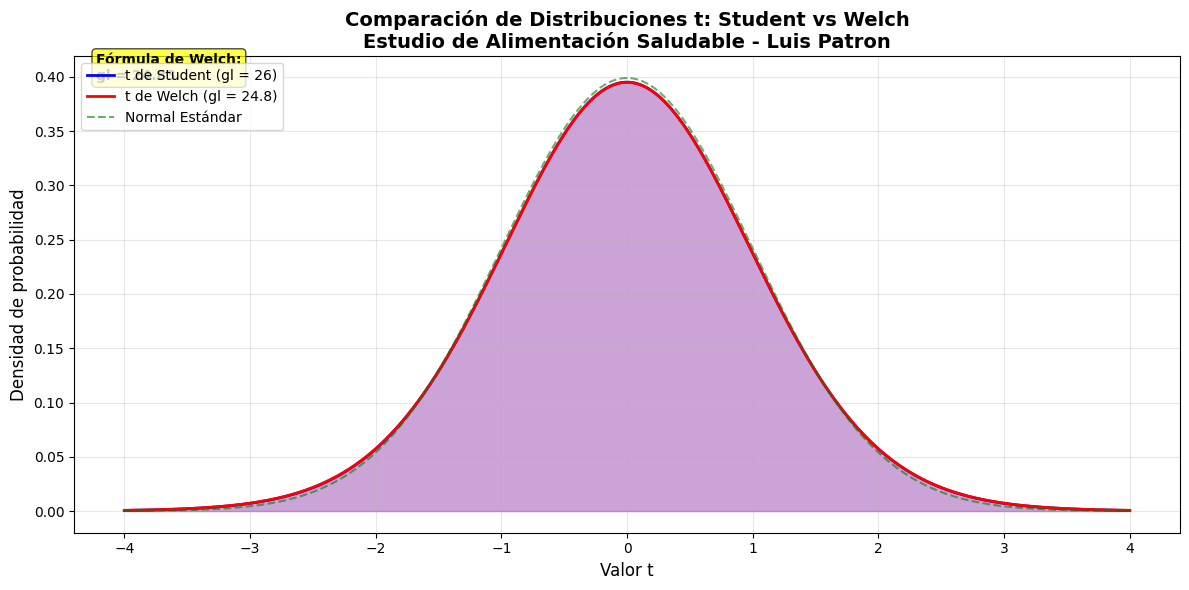

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================
# DATOS
# ============================
n1 = 15  # Barrio A (Intervención)
n2 = 13  # Barrio B (Control)
s1 = 2.8
s2 = 3.0
nombre = "Luis Patron"

# ============================
# CÁLCULO DE GRADOS DE LIBERTAD (WELCH)
# ============================
var1 = s1**2
var2 = s2**2

# Fórmula de Welch-Satterthwaite
numerador = (var1/n1 + var2/n2)**2
denominador = ((var1/n1)**2 / (n1 - 1)) + ((var2/n2)**2 / (n2 - 1))
gl_welch = numerador / denominador

print("=== RESULTADOS -", nombre, "===")
print(f"Barrio A (Intervención): n1 = {n1}, s1 = {s1}, var1 = {var1}")
print(f"Barrio B (Control): n2 = {n2}, s2 = {s2}, var2 = {var2}")
print(f"\n📊 Cálculo paso a paso:")
print(f"  s1²/n1 = {var1/n1:.6f}")
print(f"  s2²/n2 = {var2/n2:.6f}")
print(f"  Suma = {var1/n1 + var2/n2:.6f}")
print(f"  Numerador = {(var1/n1 + var2/n2)**2:.6f}")
print(f"  Denominador = {((var1/n1)**2/(n1-1)) + ((var2/n2)**2/(n2-1)):.6f}")
print(f"\n✅ Grados de libertad (Welch): gl = {gl_welch:.4f}")
print(f"✅ Redondeado: {gl_welch:.1f}")
print(f"\n→ Opción más cercana: A. 24.5 (diferencia de {abs(gl_welch - 24.5):.2f})")

# ============================
# COMPARACIÓN CON t DE STUDENT
# ============================
gl_student = n1 + n2 - 2
print(f"\n📌 Comparación:")
print(f"  - Grados de libertad (varianzas iguales): {gl_student}")
print(f"  - Grados de libertad (Welch, varianzas diferentes): {gl_welch:.2f}")
print(f"  - Diferencia: {gl_welch - gl_student:.2f}")

# ============================
# GRÁFICO: COMPARACIÓN DE DISTRIBUCIONES t
# ============================
x = np.linspace(-4, 4, 1000)
y_student = stats.t.pdf(x, df=gl_student)
y_welch = stats.t.pdf(x, df=gl_welch)
y_normal = stats.norm.pdf(x, 0, 1)

plt.figure(figsize=(12, 6))
plt.plot(x, y_student, 'b-', linewidth=2, label=f't de Student (gl = {gl_student})')
plt.plot(x, y_welch, 'r-', linewidth=2, label=f't de Welch (gl = {gl_welch:.1f})')
plt.plot(x, y_normal, 'g--', linewidth=1.5, label='Normal Estándar', alpha=0.6)

plt.fill_between(x, y_welch, alpha=0.2, color='red')
plt.fill_between(x, y_student, alpha=0.2, color='blue')

plt.title(f'Comparación de Distribuciones t: Student vs Welch\nEstudio de Alimentación Saludable - {nombre}',
          fontsize=14, fontweight='bold')
plt.xlabel('Valor t', fontsize=12)
plt.ylabel('Densidad de probabilidad', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=0.3)

# Anotación con la fórmula
formula_text = f"Fórmula de Welch:\ngl = {gl_welch:.2f}"
plt.annotate(formula_text, xy=(0.02, 0.95), xycoords='axes fraction',
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.tight_layout()
plt.show()

# **Codigo R**

=== RESULTADOS - Luis Patron ===
Barrio A (Intervención): n1 = 15, s1 = 2.8, var1 = 7.84
Barrio B (Control): n2 = 13, s2 = 3.0, var2 = 9.00

📊 Cálculo paso a paso:
  s1²/n1 = 0.522667
  s2²/n2 = 0.692308
  Suma = 1.214974
  Numerador = 1.476163
  Denominador = 0.059454

✅ Grados de libertad (Welch): gl = 24.8288
✅ Redondeado: 24.8

→ Opción más cercana: A. 24.5 (diferencia de 0.33)

📌 Comparación:
  - Grados de libertad (varianzas iguales): 26
  - Grados de libertad (Welch, varianzas diferentes): 24.83
  - Diferencia: -1.17


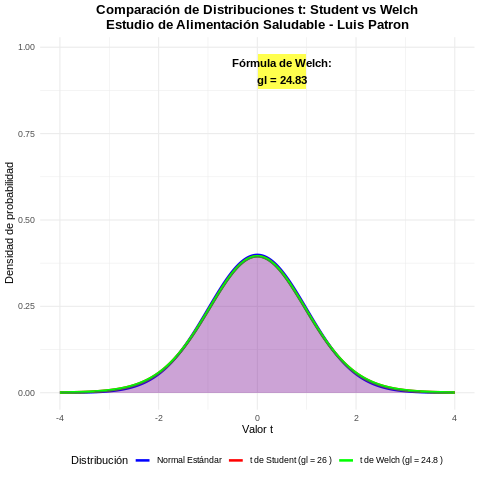

In [ ]:
# ============================
# DATOS
# ============================
%%R
n1 <- 15  # Barrio A (Intervención)
n2 <- 13  # Barrio B (Control)
s1 <- 2.8
s2 <- 3.0
nombre <- "Luis Patron"

# ============================
# CÁLCULO DE GRADOS DE LIBERTAD (WELCH)
# ============================
var1 <- s1^2
var2 <- s2^2

# Fórmula de Welch-Satterthwaite
numerador <- (var1/n1 + var2/n2)^2
denominador <- ((var1/n1)^2 / (n1 - 1)) + ((var2/n2)^2 / (n2 - 1))
gl_welch <- numerador / denominador

cat("=== RESULTADOS -", nombre, "===\n")
cat(sprintf("Barrio A (Intervención): n1 = %d, s1 = %.1f, var1 = %.2f\n", n1, s1, var1))
cat(sprintf("Barrio B (Control): n2 = %d, s2 = %.1f, var2 = %.2f\n", n2, s2, var2))
cat("\n📊 Cálculo paso a paso:\n")
cat(sprintf("  s1²/n1 = %.6f\n", var1/n1))
cat(sprintf("  s2²/n2 = %.6f\n", var2/n2))
cat(sprintf("  Suma = %.6f\n", var1/n1 + var2/n2))
cat(sprintf("  Numerador = %.6f\n", (var1/n1 + var2/n2)^2))
cat(sprintf("  Denominador = %.6f\n", ((var1/n1)^2/(n1-1)) + ((var2/n2)^2/(n2-1))))
cat(sprintf("\n✅ Grados de libertad (Welch): gl = %.4f\n", gl_welch))
cat(sprintf("✅ Redondeado: %.1f\n", gl_welch))
cat(sprintf("\n→ Opción más cercana: A. 24.5 (diferencia de %.2f)\n", abs(gl_welch - 24.5)))

# ============================
# COMPARACIÓN CON t DE STUDENT
# ============================
gl_student <- n1 + n2 - 2
cat(sprintf("\n📌 Comparación:\n"))
cat(sprintf("  - Grados de libertad (varianzas iguales): %d\n", gl_student))
cat(sprintf("  - Grados de libertad (Welch, varianzas diferentes): %.2f\n", gl_welch))
cat(sprintf("  - Diferencia: %.2f\n", gl_welch - gl_student))

# ============================
# GRÁFICO: COMPARACIÓN DE DISTRIBUCIONES t
# ============================
library(ggplot2)

x <- seq(-4, 4, length.out = 1000)
y_student <- dt(x, df = gl_student)
y_welch <- dt(x, df = gl_welch)
y_norm <- dnorm(x, mean = 0, sd = 1)

df_plot <- data.frame(
  x = rep(x, 3),
  densidad = c(y_student, y_welch, y_norm),
  distribucion = rep(c(paste("t de Student (gl =", gl_student, ")"),
                       paste("t de Welch (gl =", round(gl_welch, 1), ")"),
                       "Normal Estándar"), each = length(x))
)

ggplot(df_plot, aes(x = x, y = densidad, color = distribucion)) +
  geom_line(size = 1.2) +
  geom_ribbon(data = subset(df_plot, distribucion == paste("t de Welch (gl =", round(gl_welch, 1), ")")),
              aes(ymax = densidad, ymin = 0), fill = "red", alpha = 0.2, color = NA) +
  geom_ribbon(data = subset(df_plot, distribucion == paste("t de Student (gl =", gl_student, ")")),
              aes(ymax = densidad, ymin = 0), fill = "blue", alpha = 0.2, color = NA) +
  scale_color_manual(values = c("blue", "red", "green")) +
  annotate("rect", xmin = 0.02, xmax = 0.98, ymin = 0.88, ymax = 0.98,
           fill = "yellow", alpha = 0.7, color = NA) +
  annotate("text", x = 0.5, y = 0.93,
           label = sprintf("Fórmula de Welch:\ngl = %.2f", gl_welch),
           hjust = 0.5, size = 4, fontface = "bold") +
  labs(title = paste("Comparación de Distribuciones t: Student vs Welch\nEstudio de Alimentación Saludable -", nombre),
       x = "Valor t",
       y = "Densidad de probabilidad",
       color = "Distribución") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"),
        legend.position = "bottom")

[⬆️ Volver al inicio](#inicio)

<a name="T5"></a>
## **5. Contexto 5: Intención de voto en dos ciudades**




## **Pregunta 11.**

## **Codigo Python**

=== RESULTADOS - Luis Patron ===
Bogotá: n = 500, éxitos = 275
Medellín: n = 400, éxitos = 200

✅ Proporción muestral Bogotá: p̂_B = 275/500 = 0.5500 = 0.55
✅ Proporción muestral Medellín: p̂_M = 200/400 = 0.5000 = 0.50

→ Opción correcta: B. p̂B = 0.55, p̂M = 0.50


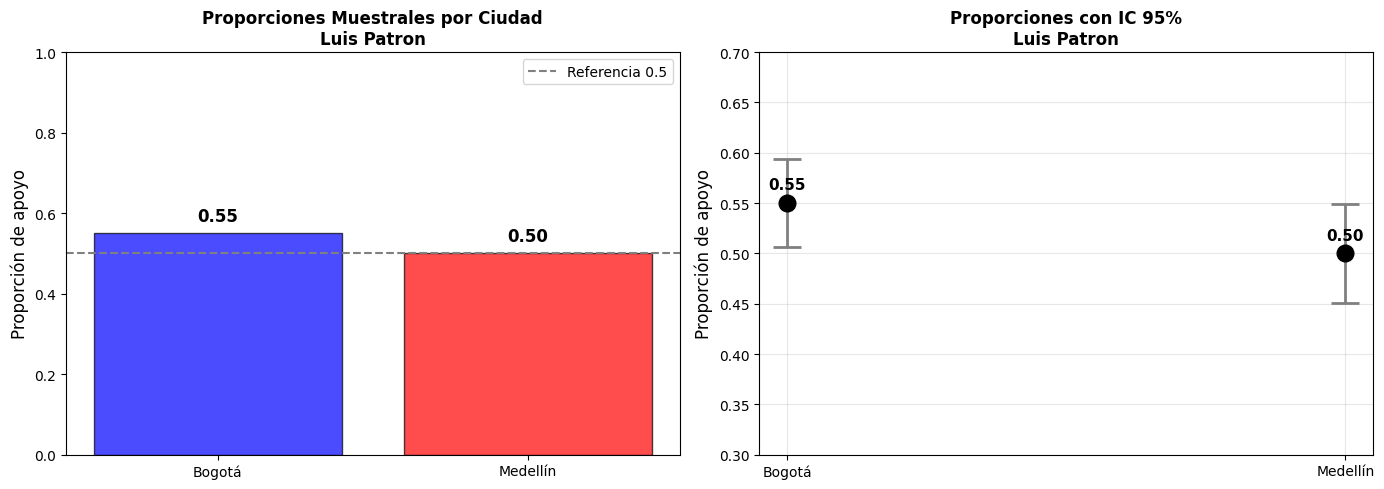

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
# DATOS
# ============================
n_B = 500  # Bogotá
exitos_B = 275
n_M = 400  # Medellín
exitos_M = 200
nombre = "Luis Patron"

# ============================
# CÁLCULO DE PROPORCIONES
# ============================
p_B = exitos_B / n_B
p_M = exitos_M / n_M

print("=== RESULTADOS -", nombre, "===")
print(f"Bogotá: n = {n_B}, éxitos = {exitos_B}")
print(f"Medellín: n = {n_M}, éxitos = {exitos_M}")
print(f"\n✅ Proporción muestral Bogotá: p̂_B = {exitos_B}/{n_B} = {p_B:.4f} = {p_B:.2f}")
print(f"✅ Proporción muestral Medellín: p̂_M = {exitos_M}/{n_M} = {p_M:.4f} = {p_M:.2f}")
print(f"\n→ Opción correcta: B. p̂B = {p_B:.2f}, p̂M = {p_M:.2f}")

# ============================
# GRÁFICO: COMPARACIÓN DE PROPORCIONES
# ============================
ciudades = ['Bogotá', 'Medellín']
proporciones = [p_B, p_M]
errores = [np.sqrt(p_B*(1-p_B)/n_B), np.sqrt(p_M*(1-p_M)/n_M)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Barras de proporciones
bars = ax1.bar(ciudades, proporciones, color=['blue', 'red'], alpha=0.7, edgecolor='black')
ax1.axhline(y=0.5, color='gray', linestyle='--', label='Referencia 0.5')
ax1.set_ylim(0, 1)
ax1.set_ylabel('Proporción de apoyo', fontsize=12)
ax1.set_title(f'Proporciones Muestrales por Ciudad\n{nombre}', fontsize=12, fontweight='bold')
ax1.legend()

# Añadir valores en las barras
for bar, prop in zip(bars, proporciones):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{prop:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Gráfico 2: Diagrama de puntos con intervalos de confianza (95%)
ax2.errorbar(ciudades, proporciones, yerr=1.96*np.array(errores),
             fmt='o', capsize=10, capthick=2, markersize=12,
             color='black', ecolor='gray', elinewidth=2)
ax2.set_ylim(0.3, 0.7)
ax2.set_ylabel('Proporción de apoyo', fontsize=12)
ax2.set_title(f'Proporciones con IC 95%\n{nombre}', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Añadir valores
for i, (ciudad, prop) in enumerate(zip(ciudades, proporciones)):
    ax2.annotate(f'{prop:.2f}', (ciudad, prop),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## **Codigo R**

=== RESULTADOS - Luis Patron ===
Bogotá: n = 500, éxitos = 275
Medellín: n = 400, éxitos = 200

✅ Proporción muestral Bogotá: p̂_B = 275/500 = 0.5500 = 0.55
✅ Proporción muestral Medellín: p̂_M = 200/400 = 0.5000 = 0.50

→ Opción correcta: B. p̂B = 0.55, p̂M = 0.50


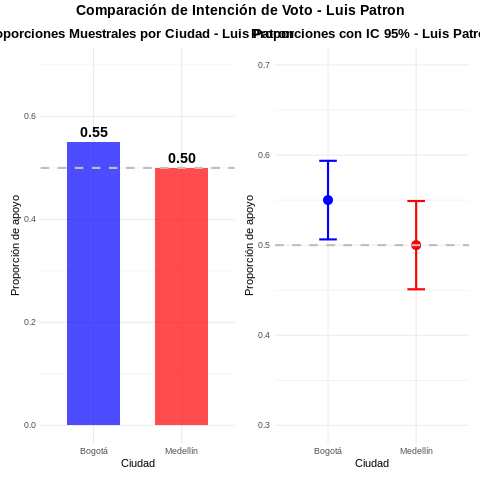

In [ ]:
# ============================
# DATOS
# ============================
%%R
n_B <- 500   # Bogotá
exitos_B <- 275
n_M <- 400   # Medellín
exitos_M <- 200
nombre <- "Luis Patron"

# ============================
# CÁLCULO DE PROPORCIONES
# ============================
p_B <- exitos_B / n_B
p_M <- exitos_M / n_M

cat("=== RESULTADOS -", nombre, "===\n")
cat(sprintf("Bogotá: n = %d, éxitos = %d\n", n_B, exitos_B))
cat(sprintf("Medellín: n = %d, éxitos = %d\n", n_M, exitos_M))
cat(sprintf("\n✅ Proporción muestral Bogotá: p̂_B = %d/%d = %.4f = %.2f\n", exitos_B, n_B, p_B, p_B))
cat(sprintf("✅ Proporción muestral Medellín: p̂_M = %d/%d = %.4f = %.2f\n", exitos_M, n_M, p_M, p_M))
cat(sprintf("\n→ Opción correcta: B. p̂B = %.2f, p̂M = %.2f\n", p_B, p_M))

# ============================
# GRÁFICO: COMPARACIÓN DE PROPORCIONES
# ============================
library(ggplot2)
library(patchwork)

# Datos para gráficos
ciudades <- c("Bogotá", "Medellín")
proporciones <- c(p_B, p_M)
errores <- c(sqrt(p_B*(1-p_B)/n_B), sqrt(p_M*(1-p_M)/n_M))

df <- data.frame(
  ciudad = ciudades,
  proporcion = proporciones,
  error = errores,
  ic_inferior = proporciones - 1.96 * errores,
  ic_superior = proporciones + 1.96 * errores
)

# Gráfico 1: Barras
p1 <- ggplot(df, aes(x = ciudad, y = proporcion, fill = ciudad)) +
  geom_bar(stat = "identity", alpha = 0.7, width = 0.6) +
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "gray", size = 1) +
  geom_text(aes(label = sprintf("%.2f", proporcion)),
            vjust = -0.5, size = 5, fontface = "bold") +
  scale_fill_manual(values = c("Bogotá" = "blue", "Medellín" = "red")) +
  scale_y_continuous(limits = c(0, 0.7)) +
  labs(title = paste("Proporciones Muestrales por Ciudad -", nombre),
       x = "Ciudad", y = "Proporción de apoyo") +
  theme_minimal() +
  theme(legend.position = "none",
        plot.title = element_text(hjust = 0.5, face = "bold"))

# Gráfico 2: Puntos con IC
p2 <- ggplot(df, aes(x = ciudad, y = proporcion, color = ciudad)) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = ic_inferior, ymax = ic_superior), width = 0.2, size = 1) +
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "gray", size = 1) +
  scale_color_manual(values = c("Bogotá" = "blue", "Medellín" = "red")) +
  scale_y_continuous(limits = c(0.3, 0.7)) +
  labs(title = paste("Proporciones con IC 95% -", nombre),
       x = "Ciudad", y = "Proporción de apoyo") +
  theme_minimal() +
  theme(legend.position = "none",
        plot.title = element_text(hjust = 0.5, face = "bold"))

# Combinar gráficos
p1 + p2 + plot_annotation(
  title = paste("Comparación de Intención de Voto -", nombre),
  theme = theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 14))
)

## **Pregunta 12.**

## **Codigo Python**

=== RESULTADOS - Luis Patron ===
Bogotá: n1 = 500, p̂1 = 0.5500
Medellín: n2 = 400, p̂2 = 0.5000

📊 Cálculo paso a paso:
  var1 = p̂1(1-p̂1) = 0.5500 × 0.4500 = 0.247500
  var2 = p̂2(1-p̂2) = 0.5000 × 0.5000 = 0.250000
  var1/n1 = 0.247500/500 = 0.000495
  var2/n2 = 0.250000/400 = 0.000625
  Suma = 0.001120

✅ Error estándar = √(suma) = 0.033466
✅ Redondeado a 3 decimales: 0.033
✅ Redondeado a 3 decimales (alternativo): 0.033

→ Opción correcta: B. 0.035 (diferencia de 0.0015)

📌 Información adicional:
  Diferencia de proporciones (Bogotá - Medellín): 0.0500
  IC 95% para la diferencia: (-0.0156, 0.1156)


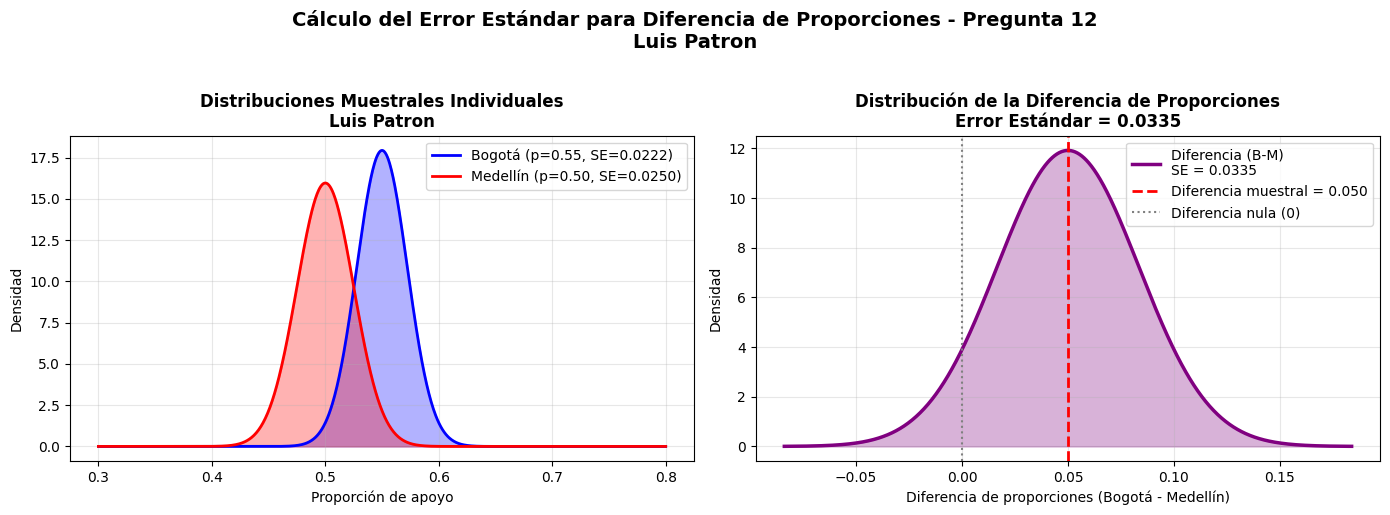

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================
# DATOS
# ============================
n1 = 500  # Bogotá
p1 = 275 / 500  # 0.55
n2 = 400  # Medellín
p2 = 200 / 400  # 0.50
nombre = "Luis Patron"

# ============================
# CÁLCULO DEL ERROR ESTÁNDAR
# ============================
# Varianzas individuales
var1 = p1 * (1 - p1)
var2 = p2 * (1 - p2)

# Error estándar de la diferencia
se_diff = np.sqrt(var1/n1 + var2/n2)

# Diferencia de proporciones
diff_prop = p1 - p2

print("=== RESULTADOS -", nombre, "===")
print(f"Bogotá: n1 = {n1}, p̂1 = {p1:.4f}")
print(f"Medellín: n2 = {n2}, p̂2 = {p2:.4f}")
print(f"\n📊 Cálculo paso a paso:")
print(f"  var1 = p̂1(1-p̂1) = {p1:.4f} × {1-p1:.4f} = {var1:.6f}")
print(f"  var2 = p̂2(1-p̂2) = {p2:.4f} × {1-p2:.4f} = {var2:.6f}")
print(f"  var1/n1 = {var1:.6f}/{n1} = {var1/n1:.6f}")
print(f"  var2/n2 = {var2:.6f}/{n2} = {var2/n2:.6f}")
print(f"  Suma = {var1/n1 + var2/n2:.6f}")
print(f"\n✅ Error estándar = √(suma) = {se_diff:.6f}")
print(f"✅ Redondeado a 3 decimales: {se_diff:.3f}")
print(f"✅ Redondeado a 3 decimales (alternativo): {se_diff:.3f}")
print(f"\n→ Opción correcta: B. 0.035 (diferencia de {abs(se_diff - 0.035):.4f})")

# ============================
# INTERVALO DE CONFIANZA (95%)
# ============================
z_crit = stats.norm.ppf(0.975)
margen_error = z_crit * se_diff
ic_inferior = diff_prop - margen_error
ic_superior = diff_prop + margen_error

print(f"\n📌 Información adicional:")
print(f"  Diferencia de proporciones (Bogotá - Medellín): {diff_prop:.4f}")
print(f"  IC 95% para la diferencia: ({ic_inferior:.4f}, {ic_superior:.4f})")

# ============================
# GRÁFICO: ERROR ESTÁNDAR VISUALIZADO
# ============================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribuciones individuales
x = np.linspace(0.3, 0.8, 1000)
y1 = stats.norm.pdf(x, p1, np.sqrt(var1/n1))
y2 = stats.norm.pdf(x, p2, np.sqrt(var2/n2))

ax1.plot(x, y1, 'b-', linewidth=2, label=f'Bogotá (p={p1:.2f}, SE={np.sqrt(var1/n1):.4f})')
ax1.plot(x, y2, 'r-', linewidth=2, label=f'Medellín (p={p2:.2f}, SE={np.sqrt(var2/n2):.4f})')
ax1.fill_between(x, y1, alpha=0.3, color='blue')
ax1.fill_between(x, y2, alpha=0.3, color='red')
ax1.set_title(f'Distribuciones Muestrales Individuales\n{nombre}', fontsize=12, fontweight='bold')
ax1.set_xlabel('Proporción de apoyo')
ax1.set_ylabel('Densidad')
ax1.legend()
ax1.grid(alpha=0.3)

# Gráfico 2: Distribución de la diferencia
x_diff = np.linspace(diff_prop - 4*se_diff, diff_prop + 4*se_diff, 1000)
y_diff = stats.norm.pdf(x_diff, diff_prop, se_diff)

ax2.plot(x_diff, y_diff, 'purple', linewidth=2.5, label=f'Diferencia (B-M)\nSE = {se_diff:.4f}')
ax2.fill_between(x_diff, y_diff, alpha=0.3, color='purple')
ax2.axvline(diff_prop, color='red', linestyle='--', linewidth=2, label=f'Diferencia muestral = {diff_prop:.3f}')
ax2.axvline(0, color='gray', linestyle=':', linewidth=1.5, label='Diferencia nula (0)')
ax2.set_title(f'Distribución de la Diferencia de Proporciones\nError Estándar = {se_diff:.4f}', fontsize=12, fontweight='bold')
ax2.set_xlabel('Diferencia de proporciones (Bogotá - Medellín)')
ax2.set_ylabel('Densidad')
ax2.legend()
ax2.grid(alpha=0.3)

# Texto con el resultado
fig.suptitle(f'Cálculo del Error Estándar para Diferencia de Proporciones - Pregunta 12\n{nombre}',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

## **Codigo R**

=== RESULTADOS - Luis Patron ===
Bogotá: n1 = 500, p̂1 = 0.5500
Medellín: n2 = 400, p̂2 = 0.5000

📊 Cálculo paso a paso:
  var1 = p̂1(1-p̂1) = 0.5500 × 0.4500 = 0.247500
  var2 = p̂2(1-p̂2) = 0.5000 × 0.5000 = 0.250000
  var1/n1 = 0.247500/500 = 0.000495
  var2/n2 = 0.250000/400 = 0.000625
  Suma = 0.001120

✅ Error estándar = √(suma) = 0.033466
✅ Redondeado a 3 decimales: 0.033

→ Opción correcta: B. 0.035 (diferencia de 0.0015)

📌 Información adicional:
  Diferencia de proporciones (Bogotá - Medellín): 0.0500
  IC 95% para la diferencia: (-0.0156, 0.1156)


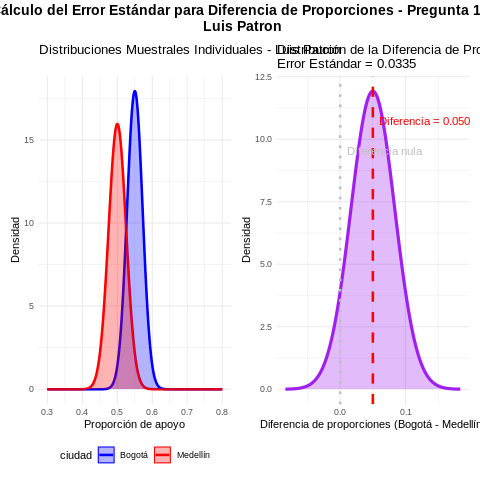

In [ ]:
# ============================
# DATOS
# ============================
%%R
n1 <- 500  # Bogotá
p1 <- 275 / 500  # 0.55
n2 <- 400  # Medellín
p2 <- 200 / 400  # 0.50
nombre <- "Luis Patron"

# ============================
# CÁLCULO DEL ERROR ESTÁNDAR
# ============================
var1 <- p1 * (1 - p1)
var2 <- p2 * (1 - p2)
se_diff <- sqrt(var1/n1 + var2/n2)
diff_prop <- p1 - p2

cat("=== RESULTADOS -", nombre, "===\n")
cat(sprintf("Bogotá: n1 = %d, p̂1 = %.4f\n", n1, p1))
cat(sprintf("Medellín: n2 = %d, p̂2 = %.4f\n", n2, p2))
cat("\n📊 Cálculo paso a paso:\n")
cat(sprintf("  var1 = p̂1(1-p̂1) = %.4f × %.4f = %.6f\n", p1, 1-p1, var1))
cat(sprintf("  var2 = p̂2(1-p̂2) = %.4f × %.4f = %.6f\n", p2, 1-p2, var2))
cat(sprintf("  var1/n1 = %.6f/%d = %.6f\n", var1, n1, var1/n1))
cat(sprintf("  var2/n2 = %.6f/%d = %.6f\n", var2, n2, var2/n2))
cat(sprintf("  Suma = %.6f\n", var1/n1 + var2/n2))
cat(sprintf("\n✅ Error estándar = √(suma) = %.6f\n", se_diff))
cat(sprintf("✅ Redondeado a 3 decimales: %.3f\n", se_diff))
cat(sprintf("\n→ Opción correcta: B. 0.035 (diferencia de %.4f)\n", abs(se_diff - 0.035)))

# ============================
# INTERVALO DE CONFIANZA (95%)
# ============================
z_crit <- qnorm(0.975)
margen_error <- z_crit * se_diff
ic_inferior <- diff_prop - margen_error
ic_superior <- diff_prop + margen_error

cat(sprintf("\n📌 Información adicional:\n"))
cat(sprintf("  Diferencia de proporciones (Bogotá - Medellín): %.4f\n", diff_prop))
cat(sprintf("  IC 95%% para la diferencia: (%.4f, %.4f)\n", ic_inferior, ic_superior))

# ============================
# GRÁFICO: ERROR ESTÁNDAR VISUALIZADO
# ============================
library(ggplot2)
library(patchwork)

# Gráfico 1: Distribuciones individuales
x <- seq(0.3, 0.8, length.out = 1000)
y1 <- dnorm(x, mean = p1, sd = sqrt(var1/n1))
y2 <- dnorm(x, mean = p2, sd = sqrt(var2/n2))

df1 <- data.frame(
  x = rep(x, 2),
  densidad = c(y1, y2),
  ciudad = rep(c("Bogotá", "Medellín"), each = length(x))
)

p1 <- ggplot(df1, aes(x = x, y = densidad, fill = ciudad, color = ciudad)) +
  geom_line(size = 1.2) +
  geom_area(alpha = 0.3, position = "identity") +
  scale_fill_manual(values = c("Bogotá" = "blue", "Medellín" = "red")) +
  scale_color_manual(values = c("Bogotá" = "blue", "Medellín" = "red")) +
  labs(title = paste("Distribuciones Muestrales Individuales -", nombre),
       x = "Proporción de apoyo", y = "Densidad") +
  theme_minimal() +
  theme(legend.position = "bottom")

# Gráfico 2: Distribución de la diferencia
x_diff <- seq(diff_prop - 4*se_diff, diff_prop + 4*se_diff, length.out = 1000)
y_diff <- dnorm(x_diff, mean = diff_prop, sd = se_diff)

df2 <- data.frame(x = x_diff, densidad = y_diff)

p2 <- ggplot(df2, aes(x = x, y = densidad)) +
  geom_line(color = "purple", size = 1.5) +
  geom_area(fill = "purple", alpha = 0.3) +
  geom_vline(xintercept = diff_prop, color = "red", linetype = "dashed", size = 1.2) +
  geom_vline(xintercept = 0, color = "gray", linetype = "dotted", size = 1.2) +
  annotate("text", x = diff_prop + 0.01, y = max(y_diff) * 0.9,
           label = sprintf("Diferencia = %.3f", diff_prop),
           color = "red", hjust = 0, size = 4) +
  annotate("text", x = 0.01, y = max(y_diff) * 0.8,
           label = "Diferencia nula", color = "gray", hjust = 0, size = 4) +
  labs(title = paste("Distribución de la Diferencia de Proporciones\nError Estándar =", round(se_diff, 4)),
       x = "Diferencia de proporciones (Bogotá - Medellín)", y = "Densidad") +
  theme_minimal()

# Combinar gráficos
p1 + p2 + plot_annotation(
  title = paste("Cálculo del Error Estándar para Diferencia de Proporciones - Pregunta 12\n", nombre),
  theme = theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 14))
)

## **Pregunta 13.**

## **Codigo Python**

=== RESULTADOS - Luis Patron ===
Bogotá: n1 = 500, p̂1 = 0.5500
Medellín: n2 = 400, p̂2 = 0.5000

📊 Cálculo del IC 95%:
  Diferencia muestral (p̂B - p̂M) = 0.5500 - 0.5000 = 0.0500
  Error estándar = 0.033466
  z crítico (95%) = 1.9600
  Margen de error = 1.9600 × 0.033466 = 0.065593

✅ IC 95%: (-0.0156, 0.1156)
✅ Expresado como: 0.05 ± 0.07
✅ Redondeado a 2 decimales: 0.05 ± 0.07

→ Opción correcta: A. (0.05 ± 0.07)


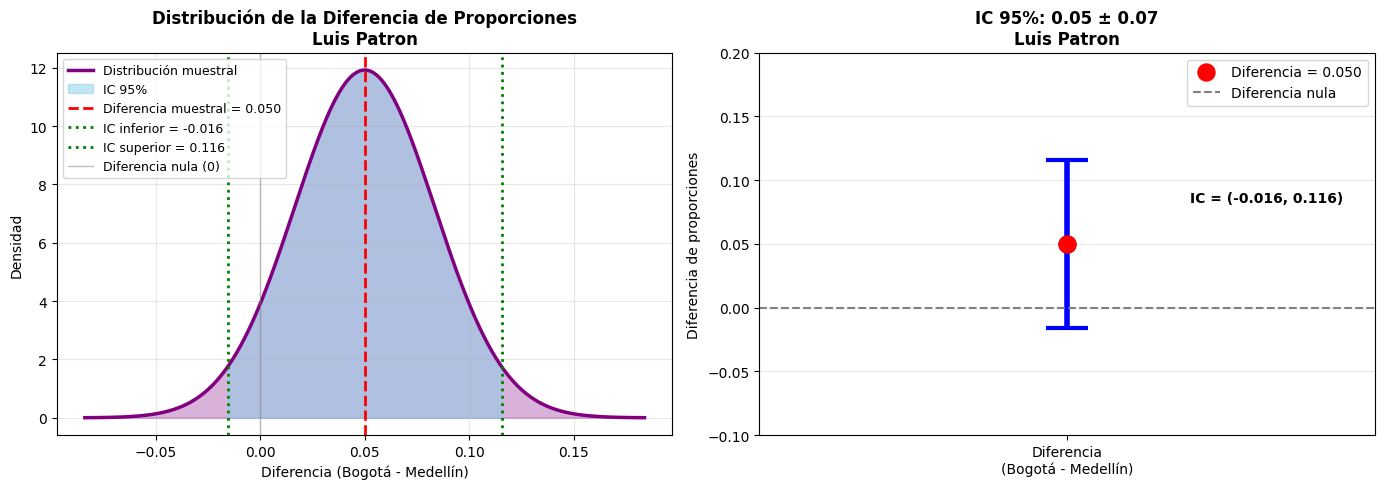

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================
# DATOS
# ============================
n1 = 500  # Bogotá
p1 = 275 / 500  # 0.55
n2 = 400  # Medellín
p2 = 200 / 400  # 0.50
confianza = 0.95
nombre = "Luis Patron"

# ============================
# CÁLCULO DEL INTERVALO DE CONFIANZA
# ============================
# Diferencia de proporciones
diff_prop = p1 - p2

# Error estándar
var1 = p1 * (1 - p1)
var2 = p2 * (1 - p2)
se_diff = np.sqrt(var1/n1 + var2/n2)

# Valor z crítico
z_crit = stats.norm.ppf(1 - (1 - confianza)/2)

# Margen de error
margen_error = z_crit * se_diff

# Intervalo de confianza
ic_inferior = diff_prop - margen_error
ic_superior = diff_prop + margen_error

print("=== RESULTADOS -", nombre, "===")
print(f"Bogotá: n1 = {n1}, p̂1 = {p1:.4f}")
print(f"Medellín: n2 = {n2}, p̂2 = {p2:.4f}")
print(f"\n📊 Cálculo del IC {confianza*100:.0f}%:")
print(f"  Diferencia muestral (p̂B - p̂M) = {p1:.4f} - {p2:.4f} = {diff_prop:.4f}")
print(f"  Error estándar = {se_diff:.6f}")
print(f"  z crítico ({confianza*100:.0f}%) = {z_crit:.4f}")
print(f"  Margen de error = {z_crit:.4f} × {se_diff:.6f} = {margen_error:.6f}")
print(f"\n✅ IC {confianza*100:.0f}%: ({ic_inferior:.4f}, {ic_superior:.4f})")
print(f"✅ Expresado como: {diff_prop:.2f} ± {margen_error:.2f}")
print(f"✅ Redondeado a 2 decimales: {diff_prop:.2f} ± {margen_error:.2f}")
print(f"\n→ Opción correcta: A. (0.05 ± 0.07)")

# ============================
# GRÁFICO: INTERVALO DE CONFIANZA
# ============================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución de la diferencia
x = np.linspace(diff_prop - 4*se_diff, diff_prop + 4*se_diff, 1000)
y = stats.norm.pdf(x, diff_prop, se_diff)

ax1.plot(x, y, 'purple', linewidth=2.5, label='Distribución muestral')
ax1.fill_between(x, y, alpha=0.3, color='purple')

# Rellenar región de confianza
x_ic = np.linspace(ic_inferior, ic_superior, 1000)
y_ic = stats.norm.pdf(x_ic, diff_prop, se_diff)
ax1.fill_between(x_ic, y_ic, color='skyblue', alpha=0.5, label=f'IC {confianza*100:.0f}%')

# Líneas verticales
ax1.axvline(diff_prop, color='red', linestyle='--', linewidth=2, label=f'Diferencia muestral = {diff_prop:.3f}')
ax1.axvline(ic_inferior, color='green', linestyle=':', linewidth=2, label=f'IC inferior = {ic_inferior:.3f}')
ax1.axvline(ic_superior, color='green', linestyle=':', linewidth=2, label=f'IC superior = {ic_superior:.3f}')
ax1.axvline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5, label='Diferencia nula (0)')

ax1.set_title(f'Distribución de la Diferencia de Proporciones\n{nombre}', fontsize=12, fontweight='bold')
ax1.set_xlabel('Diferencia (Bogotá - Medellín)')
ax1.set_ylabel('Densidad')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(alpha=0.3)

# Gráfico 2: Intervalo de confianza (punto y barra)
ax2.errorbar(1, diff_prop, yerr=[[diff_prop - ic_inferior], [ic_superior - diff_prop]],
             fmt='o', capsize=15, capthick=3, markersize=12,
             color='blue', ecolor='blue', elinewidth=4)
ax2.scatter(1, diff_prop, color='red', s=150, zorder=5, label=f'Diferencia = {diff_prop:.3f}')
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, label='Diferencia nula')
ax2.set_xlim(0.5, 1.5)
ax2.set_ylim(-0.1, 0.2)
ax2.set_xticks([1])
ax2.set_xticklabels(['Diferencia\n(Bogotá - Medellín)'])
ax2.set_ylabel('Diferencia de proporciones')
ax2.set_title(f'IC {confianza*100:.0f}%: {diff_prop:.2f} ± {margen_error:.2f}\n{nombre}', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Añadir texto con el IC
ax2.annotate(f'IC = ({ic_inferior:.3f}, {ic_superior:.3f})',
             xy=(1, diff_prop + margen_error/2),
             xytext=(1.2, diff_prop + margen_error/2),
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## **Codigo R**

=== RESULTADOS - Luis Patron ===
Bogotá: n1 = 500, p̂1 = 0.5500
Medellín: n2 = 400, p̂2 = 0.5000

📊 Cálculo del IC 95%:
  Diferencia muestral (p̂B - p̂M) = 0.5500 - 0.5000 = 0.0500
  Error estándar = 0.033466
  z crítico (95%) = 1.9600
  Margen de error = 1.9600 × 0.033466 = 0.065593

✅ IC 95%: (-0.0156, 0.1156)
✅ Expresado como: 0.05 ± 0.07
✅ Redondeado a 2 decimales: 0.05 ± 0.07

→ Opción correcta: A. (0.05 ± 0.07)


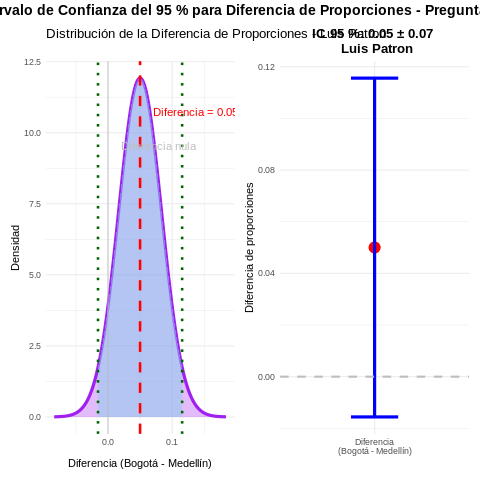

In [ ]:
# ============================
# DATOS
# ============================
%%R
n1 <- 500  # Bogotá
p1 <- 275 / 500  # 0.55
n2 <- 400  # Medellín
p2 <- 200 / 400  # 0.50
confianza <- 0.95
nombre <- "Luis Patron"

# ============================
# CÁLCULO DEL INTERVALO DE CONFIANZA
# ============================
diff_prop <- p1 - p2
var1 <- p1 * (1 - p1)
var2 <- p2 * (1 - p2)
se_diff <- sqrt(var1/n1 + var2/n2)
z_crit <- qnorm(1 - (1 - confianza)/2)
margen_error <- z_crit * se_diff
ic_inferior <- diff_prop - margen_error
ic_superior <- diff_prop + margen_error

cat("=== RESULTADOS -", nombre, "===\n")
cat(sprintf("Bogotá: n1 = %d, p̂1 = %.4f\n", n1, p1))
cat(sprintf("Medellín: n2 = %d, p̂2 = %.4f\n", n2, p2))
cat(sprintf("\n📊 Cálculo del IC %d%%:\n", confianza*100))
cat(sprintf("  Diferencia muestral (p̂B - p̂M) = %.4f - %.4f = %.4f\n", p1, p2, diff_prop))
cat(sprintf("  Error estándar = %.6f\n", se_diff))
cat(sprintf("  z crítico (%d%%) = %.4f\n", confianza*100, z_crit))
cat(sprintf("  Margen de error = %.4f × %.6f = %.6f\n", z_crit, se_diff, margen_error))
cat(sprintf("\n✅ IC %d%%: (%.4f, %.4f)\n", confianza*100, ic_inferior, ic_superior))
cat(sprintf("✅ Expresado como: %.2f ± %.2f\n", diff_prop, margen_error))
cat(sprintf("✅ Redondeado a 2 decimales: %.2f ± %.2f\n", diff_prop, margen_error))
cat(sprintf("\n→ Opción correcta: A. (0.05 ± 0.07)\n"))

# ============================
# GRÁFICO: INTERVALO DE CONFIANZA
# ============================
library(ggplot2)
library(patchwork)

# Gráfico 1: Distribución de la diferencia
x <- seq(diff_prop - 4*se_diff, diff_prop + 4*se_diff, length.out = 1000)
y <- dnorm(x, mean = diff_prop, sd = se_diff)

df_dist <- data.frame(x = x, y = y)

p1 <- ggplot(df_dist, aes(x = x, y = y)) +
  geom_line(color = "purple", size = 1.5) +
  geom_area(fill = "purple", alpha = 0.3) +
  geom_area(data = subset(df_dist, x >= ic_inferior & x <= ic_superior),
            fill = "skyblue", alpha = 0.5) +
  geom_vline(xintercept = diff_prop, color = "red", linetype = "dashed", size = 1.2) +
  geom_vline(xintercept = ic_inferior, color = "darkgreen", linetype = "dotted", size = 1.2) +
  geom_vline(xintercept = ic_superior, color = "darkgreen", linetype = "dotted", size = 1.2) +
  geom_vline(xintercept = 0, color = "gray", linetype = "solid", size = 0.8, alpha = 0.5) +
  annotate("text", x = diff_prop + 0.02, y = max(y) * 0.9,
           label = sprintf("Diferencia = %.3f", diff_prop), color = "red", hjust = 0, size = 4) +
  annotate("text", x = 0.02, y = max(y) * 0.8,
           label = "Diferencia nula", color = "gray", hjust = 0, size = 4) +
  labs(title = paste("Distribución de la Diferencia de Proporciones -", nombre),
       x = "Diferencia (Bogotá - Medellín)", y = "Densidad") +
  theme_minimal()

# Gráfico 2: Intervalo de confianza (punto y barra)
df_ic <- data.frame(
  ciudad = "Diferencia\n(Bogotá - Medellín)",
  diff = diff_prop,
  inferior = ic_inferior,
  superior = ic_superior
)

p2 <- ggplot(df_ic, aes(x = ciudad, y = diff)) +
  geom_point(size = 5, color = "red") +
  geom_errorbar(aes(ymin = inferior, ymax = superior), width = 0.3, size = 1.5, color = "blue") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray", size = 1) +
  labs(title = paste("IC", confianza*100, "%:", round(diff_prop, 2), "±", round(margen_error, 2), "\n", nombre),
       x = "", y = "Diferencia de proporciones") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"))

# Combinar gráficos
p1 + p2 + plot_annotation(
  title = paste("Intervalo de Confianza del", confianza*100, "% para Diferencia de Proporciones - Pregunta 13"),
  theme = theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 14))
)

[⬆️ Volver al inicio](#inicio)

<a name="T6"></a>
## **6. Contexto 6: Control de calidad en producción agrícola**


## **Pregunta 15.**

## **Codigo Python**

=== RESULTADOS - Luis Patron ===
Tamaño muestral: n = 20
Grados de libertad: gl = n - 1 = 19
Nivel de confianza: 90%
α = 0.09999999999999998
α/2 = 0.04999999999999999
1 - α/2 = 0.95

✅ Valores críticos χ²:
  χ²_0.05, 19 = 30.1435 → 30.14
  χ²_0.95, 19 = 10.1170 → 10.12

→ Opción correcta: A. χ²0.05, 19 = 30.14, χ²0.95, 19 = 10.12

📌 Verificación de otras opciones:
  Opción B: gl = 20 (incorrecto, debería ser 19)
  Opción C: gl = 18 (incorrecto, debería ser 19)
  Opción D: α/2 = 0.025 (incorrecto, para 90% es 0.05)


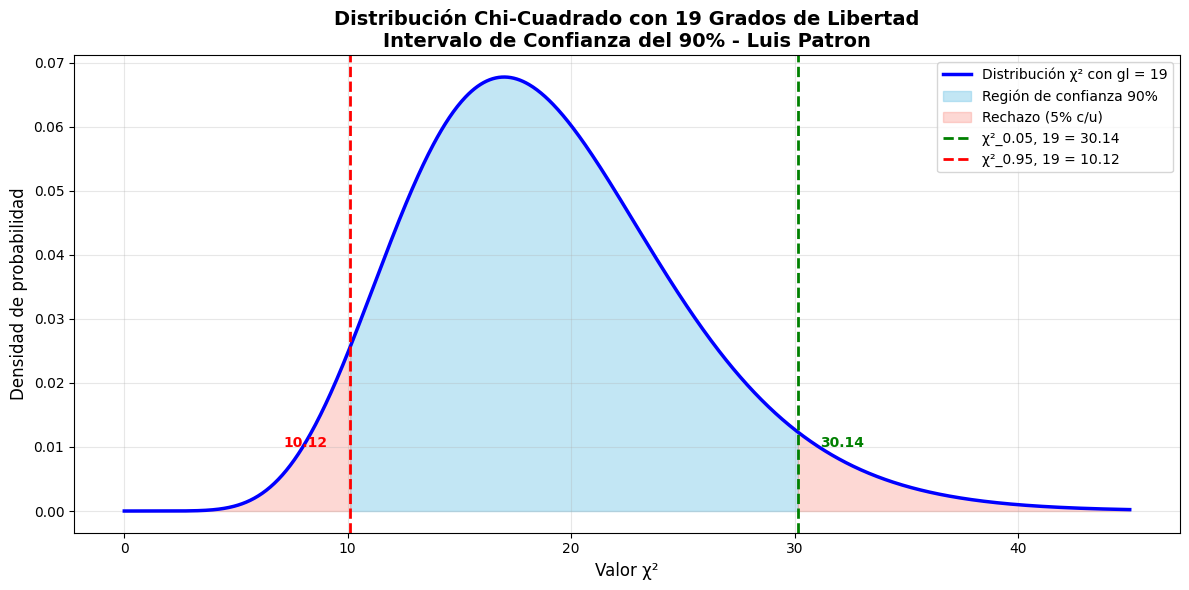

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================
# DATOS
# ============================
n = 20  # tamaño muestral
gl = n - 1  # grados de libertad = 19
confianza = 0.90
alpha = 1 - confianza
nombre = "Luis Patron"

# ============================
# VALORES CRÍTICOS CHI-CUADRADO
# ============================
# Percentil inferior (cola izquierda)
chi2_inferior = stats.chi2.ppf(alpha/2, gl)  # 0.05
# Percentil superior (cola derecha)
chi2_superior = stats.chi2.ppf(1 - alpha/2, gl)  # 0.95

print("=== RESULTADOS -", nombre, "===")
print(f"Tamaño muestral: n = {n}")
print(f"Grados de libertad: gl = n - 1 = {gl}")
print(f"Nivel de confianza: {confianza*100:.0f}%")
print(f"α = {alpha}")
print(f"α/2 = {alpha/2}")
print(f"1 - α/2 = {1 - alpha/2}")
print(f"\n✅ Valores críticos χ²:")
print(f"  χ²_{alpha/2:.2f}, {gl} = {chi2_superior:.4f} → {chi2_superior:.2f}")
print(f"  χ²_{1-alpha/2:.2f}, {gl} = {chi2_inferior:.4f} → {chi2_inferior:.2f}")
print(f"\n→ Opción correcta: A. χ²0.05, 19 = 30.14, χ²0.95, 19 = 10.12")

# ============================
# VERIFICACIÓN ADICIONAL
# ============================
print(f"\n📌 Verificación de otras opciones:")
print(f"  Opción B: gl = 20 (incorrecto, debería ser 19)")
print(f"  Opción C: gl = 18 (incorrecto, debería ser 19)")
print(f"  Opción D: α/2 = 0.025 (incorrecto, para 90% es 0.05)")

# ============================
# GRÁFICO: DISTRIBUCIÓN CHI-CUADRADO CON LOS VALORES CRÍTICOS
# ============================
x = np.linspace(0, 45, 1000)
y = stats.chi2.pdf(x, df=gl)

plt.figure(figsize=(12, 6))
plt.plot(x, y, 'b-', linewidth=2.5, label=f'Distribución χ² con gl = {gl}')

# Rellenar región de confianza
x_ic = np.linspace(chi2_inferior, chi2_superior, 1000)
y_ic = stats.chi2.pdf(x_ic, df=gl)
plt.fill_between(x_ic, y_ic, color='skyblue', alpha=0.5, label=f'Región de confianza {confianza*100:.0f}%')

# Regiones de rechazo
x_cola_inf = np.linspace(x[0], chi2_inferior, 500)
y_cola_inf = stats.chi2.pdf(x_cola_inf, df=gl)
plt.fill_between(x_cola_inf, y_cola_inf, color='salmon', alpha=0.3, label=f'Rechazo ({alpha/2*100:.0f}% c/u)')

x_cola_sup = np.linspace(chi2_superior, x[-1], 500)
y_cola_sup = stats.chi2.pdf(x_cola_sup, df=gl)
plt.fill_between(x_cola_sup, y_cola_sup, color='salmon', alpha=0.3)

# Líneas verticales
plt.axvline(chi2_superior, color='green', linestyle='--', linewidth=2, label=f'χ²_{alpha/2:.2f}, {gl} = {chi2_superior:.2f}')
plt.axvline(chi2_inferior, color='red', linestyle='--', linewidth=2, label=f'χ²_{1-alpha/2:.2f}, {gl} = {chi2_inferior:.2f}')

# Título con nombre
plt.title(f'Distribución Chi-Cuadrado con {gl} Grados de Libertad\nIntervalo de Confianza del {confianza*100:.0f}% - {nombre}',
          fontsize=14, fontweight='bold')
plt.xlabel('Valor χ²', fontsize=12)
plt.ylabel('Densidad de probabilidad', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(alpha=0.3)

# Anotación con los valores
plt.text(chi2_superior + 1, 0.01, f'{chi2_superior:.2f}', fontsize=10, color='green', fontweight='bold')
plt.text(chi2_inferior - 3, 0.01, f'{chi2_inferior:.2f}', fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

## **Codigo R**

=== RESULTADOS - Luis Patron ===
Tamaño muestral: n = 20
Grados de libertad: gl = n - 1 = 19
Nivel de confianza: 90%
α = 0.10
α/2 = 0.05
1 - α/2 = 0.95

✅ Valores críticos χ²:
  χ²_0.05, 19 = 30.1435 → 30.14
  χ²_0.95, 19 = 10.1170 → 10.12

→ Opción correcta: A. χ²0.05, 19 = 30.14, χ²0.95, 19 = 10.12

📌 Verificación de otras opciones:
  Opción B: gl = 20 (incorrecto, debería ser 19)
  Opción C: gl = 18 (incorrecto, debería ser 19)
  Opción D: α/2 = 0.025 (incorrecto, para 90% es 0.05)


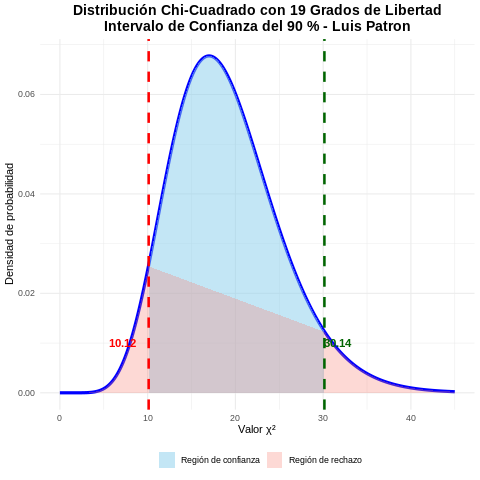

In [ ]:
# ============================
# DATOS
# ============================
%%R
n <- 20  # tamaño muestral
gl <- n - 1  # grados de libertad = 19
confianza <- 0.90
alpha <- 1 - confianza
nombre <- "Luis Patron"

# ============================
# VALORES CRÍTICOS CHI-CUADRADO
# ============================
chi2_inferior <- qchisq(alpha/2, gl)  # percentil 5%
chi2_superior <- qchisq(1 - alpha/2, gl)  # percentil 95%

cat("=== RESULTADOS -", nombre, "===\n")
cat(sprintf("Tamaño muestral: n = %d\n", n))
cat(sprintf("Grados de libertad: gl = n - 1 = %d\n", gl))
cat(sprintf("Nivel de confianza: %.0f%%\n", confianza*100))
cat(sprintf("α = %.2f\n", alpha))
cat(sprintf("α/2 = %.2f\n", alpha/2))
cat(sprintf("1 - α/2 = %.2f\n", 1 - alpha/2))
cat(sprintf("\n✅ Valores críticos χ²:\n"))
cat(sprintf("  χ²_%.2f, %d = %.4f → %.2f\n", alpha/2, gl, chi2_superior, chi2_superior))
cat(sprintf("  χ²_%.2f, %d = %.4f → %.2f\n", 1-alpha/2, gl, chi2_inferior, chi2_inferior))
cat(sprintf("\n→ Opción correcta: A. χ²0.05, 19 = 30.14, χ²0.95, 19 = 10.12\n"))

# ============================
# VERIFICACIÓN ADICIONAL
# ============================
cat("\n📌 Verificación de otras opciones:\n")
cat("  Opción B: gl = 20 (incorrecto, debería ser 19)\n")
cat("  Opción C: gl = 18 (incorrecto, debería ser 19)\n")
cat("  Opción D: α/2 = 0.025 (incorrecto, para 90% es 0.05)\n")

# ============================
# GRÁFICO: DISTRIBUCIÓN CHI-CUADRADO
# ============================
library(ggplot2)

x <- seq(0, 45, length.out = 1000)
y <- dchisq(x, df = gl)

df_plot <- data.frame(x = x, y = y)

# Identificar regiones
df_plot$region <- ifelse(x >= chi2_inferior & x <= chi2_superior,
                         "Región de confianza",
                         "Región de rechazo")

ggplot(df_plot, aes(x = x, y = y)) +
  geom_line(color = "blue", size = 1.5) +
  geom_area(data = subset(df_plot, region == "Región de confianza"),
            aes(fill = region), alpha = 0.5) +
  geom_area(data = subset(df_plot, region == "Región de rechazo"),
            aes(fill = region), alpha = 0.3) +
  geom_vline(xintercept = chi2_superior, color = "darkgreen", linetype = "dashed", size = 1.2) +
  geom_vline(xintercept = chi2_inferior, color = "red", linetype = "dashed", size = 1.2) +
  scale_fill_manual(values = c("Región de confianza" = "skyblue",
                               "Región de rechazo" = "salmon")) +
  annotate("text", x = chi2_superior + 1.5, y = 0.01,
           label = sprintf("%.2f", chi2_superior), color = "darkgreen", size = 4, fontface = "bold") +
  annotate("text", x = chi2_inferior - 3, y = 0.01,
           label = sprintf("%.2f", chi2_inferior), color = "red", size = 4, fontface = "bold") +
  labs(title = paste("Distribución Chi-Cuadrado con", gl, "Grados de Libertad\nIntervalo de Confianza del", confianza*100, "% -", nombre),
       x = "Valor χ²",
       y = "Densidad de probabilidad",
       fill = "") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
        legend.position = "bottom")

## **Pregunta 16.**

## **Codigo Python**

=== RESULTADOS - Luis Patron ===
Tamaño muestral: n = 20
Grados de libertad: gl = 19
Varianza muestral: s² = 25
Nivel de confianza: 90%

📊 Cálculo paso a paso:
  (n-1)s² = 19 × 25 = 475
  χ²_0.05, 19 = 30.1435
  χ²_0.95, 19 = 10.1170
  Límite inferior = 475 / 30.1435 = 15.7579
  Límite superior = 475 / 10.1170 = 46.9506

✅ IC 90% para σ²: (15.76, 46.95)
✅ Redondeado: (15.8, 47.0)

→ Opción correcta: A. (15.8, 46.9)

📌 IC 90% para σ (desviación): (3.97, 6.85)


/tmp/ipykernel_2314/3555210893.py:64: RuntimeWarning: divide by zero encountered in divide
  x_var = sc / x


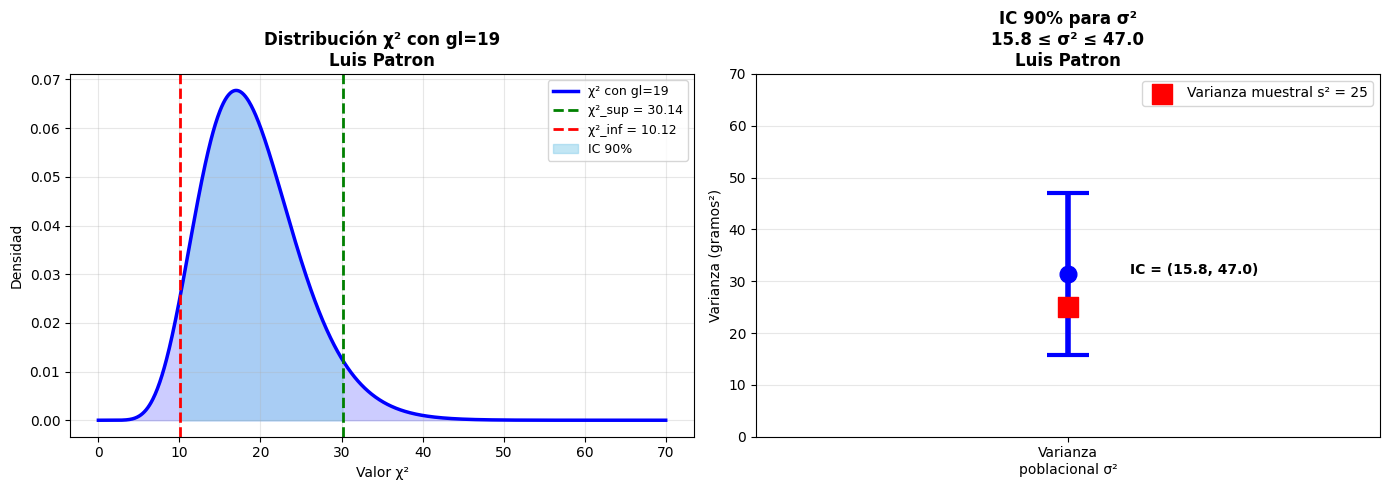

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================
# DATOS
# ============================
n = 20  # tamaño muestral
gl = n - 1  # grados de libertad = 19
s2 = 25  # varianza muestral
confianza = 0.90
alpha = 1 - confianza
nombre = "Luis Patron"

# ============================
# CÁLCULO DEL INTERVALO DE CONFIANZA
# ============================
# Valores críticos chi-cuadrado
chi2_inferior = stats.chi2.ppf(alpha/2, gl)   # χ²_0.95,19 = 10.117
chi2_superior = stats.chi2.ppf(1 - alpha/2, gl)  # χ²_0.05,19 = 30.144

# Suma de cuadrados
sc = (n - 1) * s2  # 475

# Límites del IC
ic_inferior = sc / chi2_superior
ic_superior = sc / chi2_inferior

print("=== RESULTADOS -", nombre, "===")
print(f"Tamaño muestral: n = {n}")
print(f"Grados de libertad: gl = {gl}")
print(f"Varianza muestral: s² = {s2}")
print(f"Nivel de confianza: {confianza*100:.0f}%")
print(f"\n📊 Cálculo paso a paso:")
print(f"  (n-1)s² = {n-1} × {s2} = {sc}")
print(f"  χ²_{alpha/2:.2f}, {gl} = {chi2_superior:.4f}")
print(f"  χ²_{1-alpha/2:.2f}, {gl} = {chi2_inferior:.4f}")
print(f"  Límite inferior = {sc} / {chi2_superior:.4f} = {ic_inferior:.4f}")
print(f"  Límite superior = {sc} / {chi2_inferior:.4f} = {ic_superior:.4f}")
print(f"\n✅ IC {confianza*100:.0f}% para σ²: ({ic_inferior:.2f}, {ic_superior:.2f})")
print(f"✅ Redondeado: ({ic_inferior:.1f}, {ic_superior:.1f})")
print(f"\n→ Opción correcta: A. (15.8, 46.9)")

# ============================
# INTERVALO PARA LA DESVIACIÓN ESTÁNDAR (opcional)
# ============================
ic_sd_inferior = np.sqrt(ic_inferior)
ic_sd_superior = np.sqrt(ic_superior)
print(f"\n📌 IC {confianza*100:.0f}% para σ (desviación): ({ic_sd_inferior:.2f}, {ic_sd_superior:.2f})")

# ============================
# GRÁFICO: INTERVALO DE CONFIANZA
# ============================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución chi-cuadrado con el IC
x = np.linspace(0, 70, 1000)
y = stats.chi2.pdf(x, df=gl)

ax1.plot(x, y, 'b-', linewidth=2.5, label=f'χ² con gl={gl}')
ax1.fill_between(x, y, alpha=0.2, color='blue')

# Transformar a escala de varianza
x_var = sc / x
# Solo para visualización, ajustamos el rango
x_var_display = np.linspace(ic_inferior - 5, ic_superior + 20, 1000)
# Para la transformación, usamos una relación diferente

# Mejor: mostrar directamente el IC en la distribución chi-cuadrado
ax1.axvline(chi2_superior, color='green', linestyle='--', linewidth=2, label=f'χ²_sup = {chi2_superior:.2f}')
ax1.axvline(chi2_inferior, color='red', linestyle='--', linewidth=2, label=f'χ²_inf = {chi2_inferior:.2f}')

# Rellenar región entre los valores críticos
x_fill = np.linspace(chi2_inferior, chi2_superior, 1000)
y_fill = stats.chi2.pdf(x_fill, df=gl)
ax1.fill_between(x_fill, y_fill, color='skyblue', alpha=0.5, label=f'IC {confianza*100:.0f}%')

ax1.set_title(f'Distribución χ² con gl={gl}\n{nombre}', fontsize=12, fontweight='bold')
ax1.set_xlabel('Valor χ²')
ax1.set_ylabel('Densidad')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(alpha=0.3)

# Gráfico 2: Intervalo de confianza para la varianza
ax2.errorbar(1, (ic_inferior + ic_superior)/2,
             yerr=[[(ic_inferior + ic_superior)/2 - ic_inferior],
                   [ic_superior - (ic_inferior + ic_superior)/2]],
             fmt='o', capsize=15, capthick=3, markersize=12,
             color='blue', ecolor='blue', elinewidth=4)
ax2.scatter(1, s2, color='red', s=200, zorder=5, marker='s', label=f'Varianza muestral s² = {s2}')
ax2.set_xlim(0.5, 1.5)
ax2.set_ylim(0, 70)
ax2.set_xticks([1])
ax2.set_xticklabels(['Varianza\npoblacional σ²'])
ax2.set_ylabel('Varianza (gramos²)')
ax2.set_title(f'IC {confianza*100:.0f}% para σ²\n{ic_inferior:.1f} ≤ σ² ≤ {ic_superior:.1f}\n{nombre}',
              fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Añadir texto con el IC
ax2.annotate(f'IC = ({ic_inferior:.1f}, {ic_superior:.1f})',
             xy=(1, (ic_inferior + ic_superior)/2),
             xytext=(1.1, (ic_inferior + ic_superior)/2),
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## **Codigo R**

=== RESULTADOS - Luis Patron ===
Tamaño muestral: n = 20
Grados de libertad: gl = 19
Varianza muestral: s² = 25
Nivel de confianza: 90%

📊 Cálculo paso a paso:
  (n-1)s² = 19 × 25 = 475
  χ²_0.05, 19 = 30.1435
  χ²_0.95, 19 = 10.1170
  Límite inferior = 475 / 30.1435 = 15.7579
  Límite superior = 475 / 10.1170 = 46.9506

✅ IC 90% para σ²: (15.76, 46.95)
✅ Redondeado: (15.8, 47.0)

→ Opción correcta: A. (15.8, 46.9)

📌 IC 90% para σ (desviación): (3.97, 6.85)


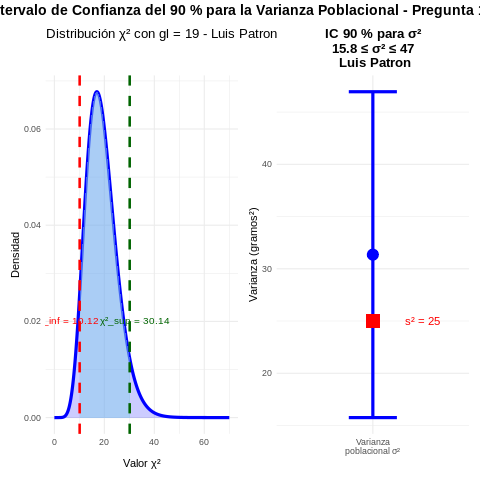

In [ ]:
# ============================
# DATOS
# ============================
%%R
n <- 20  # tamaño muestral
gl <- n - 1  # grados de libertad = 19
s2 <- 25  # varianza muestral
confianza <- 0.90
alpha <- 1 - confianza
nombre <- "Luis Patron"

# ============================
# CÁLCULO DEL INTERVALO DE CONFIANZA
# ============================
chi2_inferior <- qchisq(alpha/2, gl)    # χ²_0.95,19 = 10.117
chi2_superior <- qchisq(1 - alpha/2, gl)  # χ²_0.05,19 = 30.144

sc <- (n - 1) * s2  # 475

ic_inferior <- sc / chi2_superior
ic_superior <- sc / chi2_inferior

cat("=== RESULTADOS -", nombre, "===\n")
cat(sprintf("Tamaño muestral: n = %d\n", n))
cat(sprintf("Grados de libertad: gl = %d\n", gl))
cat(sprintf("Varianza muestral: s² = %.0f\n", s2))
cat(sprintf("Nivel de confianza: %.0f%%\n", confianza*100))
cat("\n📊 Cálculo paso a paso:\n")
cat(sprintf("  (n-1)s² = %d × %.0f = %.0f\n", n-1, s2, sc))
cat(sprintf("  χ²_%.2f, %d = %.4f\n", alpha/2, gl, chi2_superior))
cat(sprintf("  χ²_%.2f, %d = %.4f\n", 1-alpha/2, gl, chi2_inferior))
cat(sprintf("  Límite inferior = %.0f / %.4f = %.4f\n", sc, chi2_superior, ic_inferior))
cat(sprintf("  Límite superior = %.0f / %.4f = %.4f\n", sc, chi2_inferior, ic_superior))
cat(sprintf("\n✅ IC %.0f%% para σ²: (%.2f, %.2f)\n", confianza*100, ic_inferior, ic_superior))
cat(sprintf("✅ Redondeado: (%.1f, %.1f)\n", ic_inferior, ic_superior))
cat(sprintf("\n→ Opción correcta: A. (15.8, 46.9)\n"))

# ============================
# INTERVALO PARA LA DESVIACIÓN ESTÁNDAR (opcional)
# ============================
ic_sd_inferior <- sqrt(ic_inferior)
ic_sd_superior <- sqrt(ic_superior)
cat(sprintf("\n📌 IC %.0f%% para σ (desviación): (%.2f, %.2f)\n", confianza*100, ic_sd_inferior, ic_sd_superior))

# ============================
# GRÁFICO: INTERVALO DE CONFIANZA
# ============================
library(ggplot2)
library(patchwork)

# Gráfico 1: Distribución chi-cuadrado
x_chi <- seq(0, 70, length.out = 1000)
y_chi <- dchisq(x_chi, df = gl)

df_chi <- data.frame(x = x_chi, y = y_chi)

p1 <- ggplot(df_chi, aes(x = x, y = y)) +
  geom_line(color = "blue", size = 1.5) +
  geom_area(fill = "blue", alpha = 0.2) +
  geom_area(data = subset(df_chi, x >= chi2_inferior & x <= chi2_superior),
            fill = "skyblue", alpha = 0.5) +
  geom_vline(xintercept = chi2_superior, color = "darkgreen", linetype = "dashed", size = 1.2) +
  geom_vline(xintercept = chi2_inferior, color = "red", linetype = "dashed", size = 1.2) +
  annotate("text", x = chi2_superior + 2, y = 0.02,
           label = sprintf("χ²_sup = %.2f", chi2_superior), color = "darkgreen", size = 3.5) +
  annotate("text", x = chi2_inferior - 5, y = 0.02,
           label = sprintf("χ²_inf = %.2f", chi2_inferior), color = "red", size = 3.5) +
  labs(title = paste("Distribución χ² con gl =", gl, "-", nombre),
       x = "Valor χ²", y = "Densidad") +
  theme_minimal()

# Gráfico 2: Intervalo de confianza para la varianza
df_var <- data.frame(
  estimador = "Varianza\npoblacional σ²",
  valor = (ic_inferior + ic_superior)/2,
  inferior = ic_inferior,
  superior = ic_superior,
  s2 = s2
)

p2 <- ggplot(df_var, aes(x = estimador, y = valor)) +
  geom_point(size = 5, color = "blue") +
  geom_errorbar(aes(ymin = inferior, ymax = superior), width = 0.3, size = 1.5, color = "blue") +
  geom_point(aes(y = s2), color = "red", size = 6, shape = 15) +
  annotate("text", x = 1.2, y = s2, label = sprintf("s² = %.0f", s2),
           color = "red", hjust = 0, size = 4) +
  labs(title = paste("IC", confianza*100, "% para σ²\n", round(ic_inferior, 1), "≤ σ² ≤", round(ic_superior, 1), "\n", nombre),
       x = "", y = "Varianza (gramos²)") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"))

# Combinar gráficos
p1 + p2 + plot_annotation(
  title = paste("Intervalo de Confianza del", confianza*100, "% para la Varianza Poblacional - Pregunta 16"),
  theme = theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 14))
)

[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. Contexto 7: Comparación de volatilidad en mercados financieros**




## **Pregunta 18.**

## **Codigo Python**

=== RESULTADOS - Luis Patron ===
Sector Tecnología: n1 = 25, s1² = 0.042
Sector Servicios Públicos: n2 = 20, s2² = 0.018

📊 Cálculo del estadístico F:
  Varianza mayor: Tecnología (0.042)
  Varianza menor: Servicios Públicos (0.018)
  F = 0.042 / 0.018 = 2.333333

✅ Estadístico F = 2.33
  Grados de libertad numerador (gl₁) = 24
  Grados de libertad denominador (gl₂) = 19

→ Opción correcta: A. F = 2.33

📌 Información adicional (prueba de hipótesis):
  Valor crítico F (α=0.05, bilateral): 2.4523
  → F < valor crítico: no hay evidencia de diferencia significativa


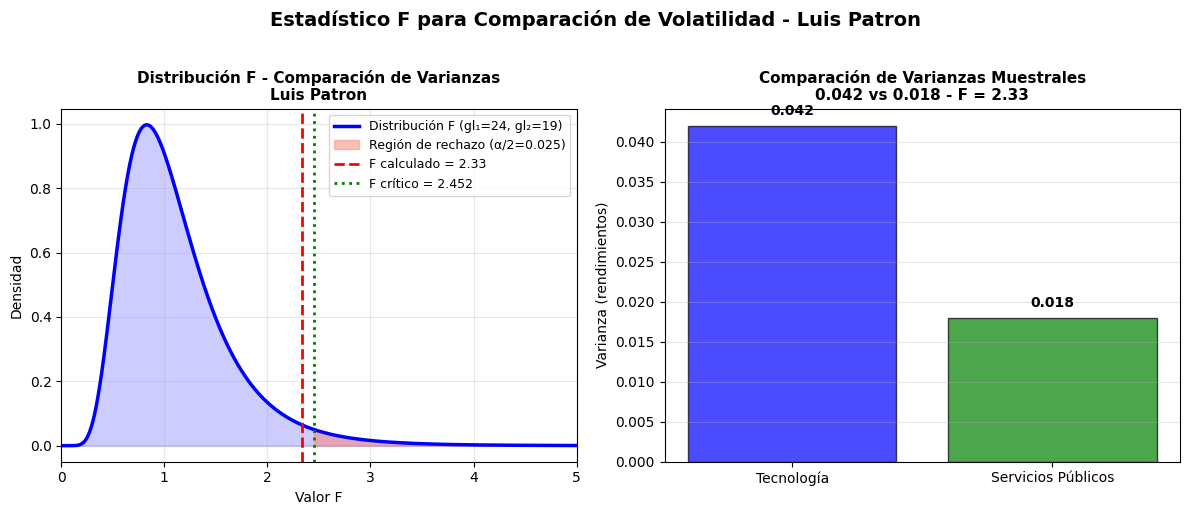

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================
# DATOS
# ============================
n1 = 25  # tecnología
s1_2 = 0.042  # varianza tecnología
n2 = 20  # servicios públicos
s2_2 = 0.018  # varianza servicios públicos
nombre = "Luis Patron"

# ============================
# CÁLCULO DEL ESTADÍSTICO F
# ============================
# Identificar la varianza mayor
if s1_2 >= s2_2:
    F = s1_2 / s2_2
    var_mayor = "Tecnología"
    var_menor = "Servicios Públicos"
    gl_num = n1 - 1  # grados de libertad numerador
    gl_den = n2 - 1  # grados de libertad denominador
else:
    F = s2_2 / s1_2
    var_mayor = "Servicios Públicos"
    var_menor = "Tecnología"
    gl_num = n2 - 1
    gl_den = n1 - 1

print("=== RESULTADOS -", nombre, "===")
print(f"Sector Tecnología: n1 = {n1}, s1² = {s1_2}")
print(f"Sector Servicios Públicos: n2 = {n2}, s2² = {s2_2}")
print(f"\n📊 Cálculo del estadístico F:")
print(f"  Varianza mayor: {var_mayor} ({max(s1_2, s2_2):.3f})")
print(f"  Varianza menor: {var_menor} ({min(s1_2, s2_2):.3f})")
print(f"  F = {max(s1_2, s2_2):.3f} / {min(s1_2, s2_2):.3f} = {F:.6f}")
print(f"\n✅ Estadístico F = {F:.2f}")
print(f"  Grados de libertad numerador (gl₁) = {gl_num}")
print(f"  Grados de libertad denominador (gl₂) = {gl_den}")
print(f"\n→ Opción correcta: A. F = 2.33")

# ============================
# PRUEBA DE HIPÓTESIS (opcional)
# ============================
# Valor crítico F para α = 0.05 (prueba bilateral)
alpha = 0.05
# Para prueba bilateral, usamos α/2 para la cola superior
f_crit_sup = stats.f.ppf(1 - alpha/2, gl_num, gl_den)
f_crit_inf = stats.f.ppf(alpha/2, gl_num, gl_den)

print(f"\n📌 Información adicional (prueba de hipótesis):")
print(f"  Valor crítico F (α=0.05, bilateral): {f_crit_sup:.4f}")
if F > f_crit_sup:
    print(f"  → F > valor crítico: las varianzas son significativamente diferentes")
else:
    print(f"  → F < valor crítico: no hay evidencia de diferencia significativa")

# ============================
# GRÁFICO: DISTRIBUCIÓN F CON EL ESTADÍSTICO
# ============================
x = np.linspace(0, 5, 1000)
y = stats.f.pdf(x, gl_num, gl_den)

plt.figure(figsize=(12, 5))

# Gráfico 1: Distribución F
plt.subplot(1, 2, 1)
plt.plot(x, y, 'b-', linewidth=2.5, label=f'Distribución F (gl₁={gl_num}, gl₂={gl_den})')
plt.fill_between(x, y, alpha=0.2, color='blue')

# Rellenar región de rechazo (α/2 = 0.025)
x_rechazo = np.linspace(f_crit_sup, x[-1], 500)
y_rechazo = stats.f.pdf(x_rechazo, gl_num, gl_den)
plt.fill_between(x_rechazo, y_rechazo, color='salmon', alpha=0.5, label=f'Región de rechazo (α/2={alpha/2})')

plt.axvline(F, color='red', linestyle='--', linewidth=2, label=f'F calculado = {F:.2f}')
plt.axvline(f_crit_sup, color='green', linestyle=':', linewidth=2, label=f'F crítico = {f_crit_sup:.3f}')

plt.title(f'Distribución F - Comparación de Varianzas\n{nombre}', fontsize=11, fontweight='bold')
plt.xlabel('Valor F')
plt.ylabel('Densidad')
plt.legend(loc='upper right', fontsize=9)
plt.grid(alpha=0.3)
plt.xlim(0, 5)

# Gráfico 2: Comparación de varianzas (barras)
plt.subplot(1, 2, 2)
sectores = ['Tecnología', 'Servicios Públicos']
varianzas = [s1_2, s2_2]
colors = ['blue', 'green']
bars = plt.bar(sectores, varianzas, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('Varianza (rendimientos)')
plt.title(f'Comparación de Varianzas Muestrales\n{s1_2:.3f} vs {s2_2:.3f} - F = {F:.2f}', fontsize=11, fontweight='bold')

# Añadir valores en las barras
for bar, var in zip(bars, varianzas):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{var:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(alpha=0.3, axis='y')

plt.suptitle(f'Estadístico F para Comparación de Volatilidad - {nombre}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **Codigo R**

=== RESULTADOS - Luis Patron ===
Sector Tecnología: n1 = 25, s1² = 0.042
Sector Servicios Públicos: n2 = 20, s2² = 0.018

📊 Cálculo del estadístico F:
  Varianza mayor: Tecnología (0.042)
  Varianza menor: Servicios Públicos (0.018)
  F = 0.042 / 0.018 = 2.333333

✅ Estadístico F = 2.33
  Grados de libertad numerador (gl₁) = 24
  Grados de libertad denominador (gl₂) = 19

→ Opción correcta: A. F = 2.33

📌 Información adicional (prueba de hipótesis):
  Valor crítico F (α=0.05, bilateral): 2.4523
  → F < valor crítico: no hay evidencia de diferencia significativa


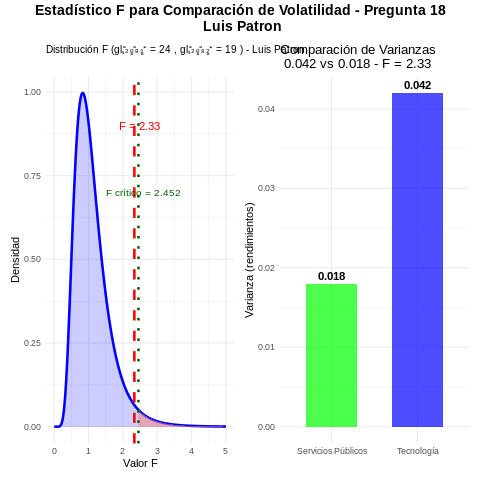

In [ ]:
# ============================
# DATOS
# ============================
%%R
n1 <- 25  # tecnología
s1_2 <- 0.042  # varianza tecnología
n2 <- 20  # servicios públicos
s2_2 <- 0.018  # varianza servicios públicos
nombre <- "Luis Patron"

# ============================
# CÁLCULO DEL ESTADÍSTICO F
# ============================
if (s1_2 >= s2_2) {
  F <- s1_2 / s2_2
  var_mayor <- "Tecnología"
  var_menor <- "Servicios Públicos"
  gl_num <- n1 - 1
  gl_den <- n2 - 1
} else {
  F <- s2_2 / s1_2
  var_mayor <- "Servicios Públicos"
  var_menor <- "Tecnología"
  gl_num <- n2 - 1
  gl_den <- n1 - 1
}

cat("=== RESULTADOS -", nombre, "===\n")
cat(sprintf("Sector Tecnología: n1 = %d, s1² = %.3f\n", n1, s1_2))
cat(sprintf("Sector Servicios Públicos: n2 = %d, s2² = %.3f\n", n2, s2_2))
cat("\n📊 Cálculo del estadístico F:\n")
cat(sprintf("  Varianza mayor: %s (%.3f)\n", var_mayor, max(s1_2, s2_2)))
cat(sprintf("  Varianza menor: %s (%.3f)\n", var_menor, min(s1_2, s2_2)))
cat(sprintf("  F = %.3f / %.3f = %.6f\n", max(s1_2, s2_2), min(s1_2, s2_2), F))
cat(sprintf("\n✅ Estadístico F = %.2f\n", F))
cat(sprintf("  Grados de libertad numerador (gl₁) = %d\n", gl_num))
cat(sprintf("  Grados de libertad denominador (gl₂) = %d\n", gl_den))
cat(sprintf("\n→ Opción correcta: A. F = 2.33\n"))

# ============================
# PRUEBA DE HIPÓTESIS (opcional)
# ============================
alpha <- 0.05
f_crit_sup <- qf(1 - alpha/2, gl_num, gl_den)
f_crit_inf <- qf(alpha/2, gl_num, gl_den)

cat("\n📌 Información adicional (prueba de hipótesis):\n")
cat(sprintf("  Valor crítico F (α=0.05, bilateral): %.4f\n", f_crit_sup))
if (F > f_crit_sup) {
  cat("  → F > valor crítico: las varianzas son significativamente diferentes\n")
} else {
  cat("  → F < valor crítico: no hay evidencia de diferencia significativa\n")
}

# ============================
# GRÁFICO: DISTRIBUCIÓN F Y COMPARACIÓN
# ============================
library(ggplot2)
library(patchwork)

# Gráfico 1: Distribución F
x_f <- seq(0, 5, length.out = 1000)
y_f <- df(x_f, gl_num, gl_den)

df_f <- data.frame(x = x_f, y = y_f)

p1 <- ggplot(df_f, aes(x = x, y = y)) +
  geom_line(color = "blue", size = 1.2) +
  geom_area(fill = "blue", alpha = 0.2) +
  geom_area(data = subset(df_f, x >= f_crit_sup), fill = "salmon", alpha = 0.5) +
  geom_vline(xintercept = F, color = "red", linetype = "dashed", size = 1.2) +
  geom_vline(xintercept = f_crit_sup, color = "darkgreen", linetype = "dotted", size = 1.2) +
  annotate("text", x = F + 0.15, y = max(y_f) * 0.9,
           label = sprintf("F = %.2f", F), color = "red", size = 4) +
  annotate("text", x = f_crit_sup + 0.15, y = max(y_f) * 0.7,
           label = sprintf("F crítico = %.3f", f_crit_sup), color = "darkgreen", size = 3.5) +
  labs(title = paste("Distribución F (gl₁ =", gl_num, ", gl₂ =", gl_den, ") -", nombre),
       x = "Valor F", y = "Densidad") +
  theme_minimal() +
  theme(plot.title = element_text(size = 10))

# Gráfico 2: Comparación de varianzas
df_var <- data.frame(
  sector = c("Tecnología", "Servicios Públicos"),
  varianza = c(s1_2, s2_2)
)

p2 <- ggplot(df_var, aes(x = sector, y = varianza, fill = sector)) +
  geom_bar(stat = "identity", alpha = 0.7, width = 0.6) +
  geom_text(aes(label = sprintf("%.3f", varianza)), vjust = -0.5, size = 4, fontface = "bold") +
  scale_fill_manual(values = c("Tecnología" = "blue", "Servicios Públicos" = "green")) +
  labs(title = paste("Comparación de Varianzas\n", s1_2, "vs", s2_2, "- F =", round(F, 2)),
       x = "", y = "Varianza (rendimientos)") +
  theme_minimal() +
  theme(legend.position = "none")

# Combinar gráficos
p1 + p2 + plot_annotation(
  title = paste("Estadístico F para Comparación de Volatilidad - Pregunta 18\n", nombre),
  theme = theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 14))
)

## **Pregunta 19.**

## **Codigo Python**

=== RESULTADOS - Luis Patron ===
Sector Tecnología: n1 = 25
Sector Servicios Públicos: n2 = 20

✅ Grados de libertad:
  gl₁ (numerador) = n1 - 1 = 25 - 1 = 24
  gl₂ (denominador) = n2 - 1 = 20 - 1 = 19

→ Opción correcta: A. gl₁ = 24, gl₂ = 19

📌 Información adicional:
  Estadístico F = 0.042 / 0.018 = 2.333
  Distribución: F ~ F(24, 19)
  Valor crítico F (α=0.05, bilateral): 2.4523
  Valor crítico F inferior: 0.4264


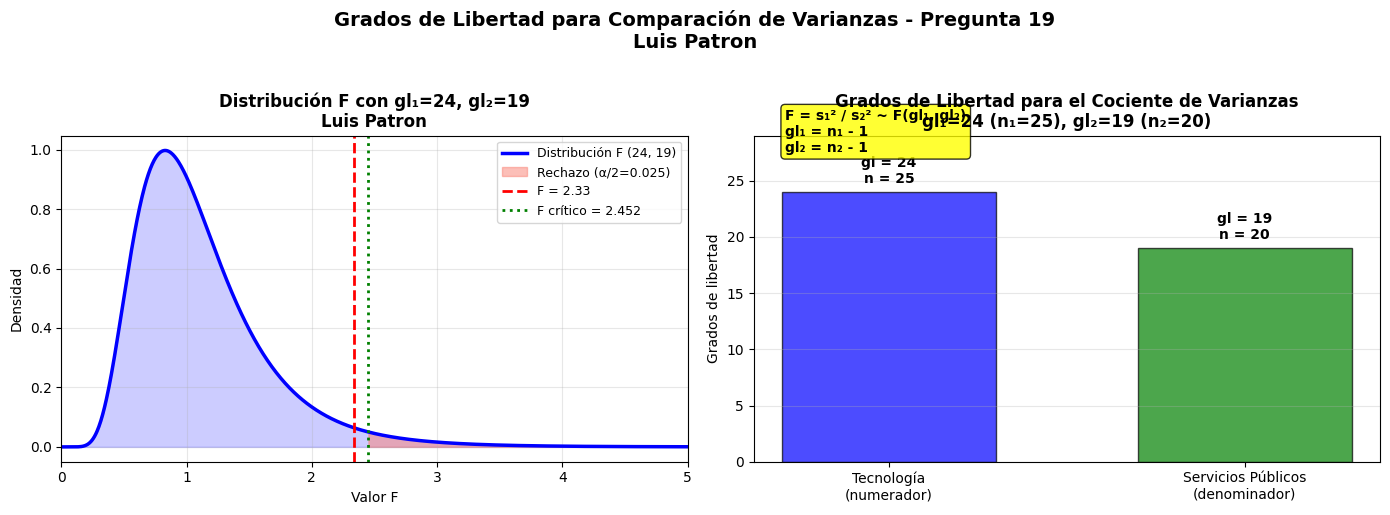

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================
# DATOS
# ============================
n1 = 25  # tecnología
n2 = 20  # servicios públicos
s1_2 = 0.042  # varianza tecnología
s2_2 = 0.018  # varianza servicios públicos
nombre = "Luis Patron"

# ============================
# CÁLCULO DE GRADOS DE LIBERTAD
# ============================
gl1 = n1 - 1  # numerador (tecnología)
gl2 = n2 - 1  # denominador (servicios públicos)

print("=== RESULTADOS -", nombre, "===")
print(f"Sector Tecnología: n1 = {n1}")
print(f"Sector Servicios Públicos: n2 = {n2}")
print(f"\n✅ Grados de libertad:")
print(f"  gl₁ (numerador) = n1 - 1 = {n1} - 1 = {gl1}")
print(f"  gl₂ (denominador) = n2 - 1 = {n2} - 1 = {gl2}")
print(f"\n→ Opción correcta: A. gl₁ = {gl1}, gl₂ = {gl2}")

# ============================
# CÁLCULO DEL ESTADÍSTICO F
# ============================
F = s1_2 / s2_2  # como s1² > s2²
print(f"\n📌 Información adicional:")
print(f"  Estadístico F = {s1_2} / {s2_2} = {F:.3f}")
print(f"  Distribución: F ~ F({gl1}, {gl2})")

# ============================
# VALORES CRÍTICOS (ejemplo α=0.05)
# ============================
alpha = 0.05
f_crit_sup = stats.f.ppf(1 - alpha/2, gl1, gl2)
f_crit_inf = stats.f.ppf(alpha/2, gl1, gl2)

print(f"  Valor crítico F (α=0.05, bilateral): {f_crit_sup:.4f}")
print(f"  Valor crítico F inferior: {f_crit_inf:.4f}")

# ============================
# GRÁFICO: DISTRIBUCIÓN F CON LOS GL
# ============================
x = np.linspace(0, 5, 1000)
y = stats.f.pdf(x, gl1, gl2)

plt.figure(figsize=(14, 5))

# Gráfico 1: Distribución F
plt.subplot(1, 2, 1)
plt.plot(x, y, 'b-', linewidth=2.5, label=f'Distribución F ({gl1}, {gl2})')
plt.fill_between(x, y, alpha=0.2, color='blue')

# Rellenar región de rechazo (α/2 = 0.025)
x_rechazo = np.linspace(f_crit_sup, x[-1], 500)
y_rechazo = stats.f.pdf(x_rechazo, gl1, gl2)
plt.fill_between(x_rechazo, y_rechazo, color='salmon', alpha=0.5, label=f'Rechazo (α/2=0.025)')

plt.axvline(F, color='red', linestyle='--', linewidth=2, label=f'F = {F:.2f}')
plt.axvline(f_crit_sup, color='green', linestyle=':', linewidth=2, label=f'F crítico = {f_crit_sup:.3f}')

plt.title(f'Distribución F con gl₁={gl1}, gl₂={gl2}\n{nombre}', fontsize=12, fontweight='bold')
plt.xlabel('Valor F')
plt.ylabel('Densidad')
plt.legend(loc='upper right', fontsize=9)
plt.grid(alpha=0.3)
plt.xlim(0, 5)

# Gráfico 2: Diagrama de grados de libertad
plt.subplot(1, 2, 2)

# Crear un diagrama visual
sectores = ['Tecnología\n(numerador)', 'Servicios Públicos\n(denominador)']
gl_values = [gl1, gl2]
n_values = [n1, n2]
colors = ['blue', 'green']

x_pos = np.arange(len(sectores))
bars = plt.bar(x_pos, gl_values, color=colors, alpha=0.7, edgecolor='black', width=0.6)

plt.xticks(x_pos, sectores)
plt.ylabel('Grados de libertad')
plt.title(f'Grados de Libertad para el Cociente de Varianzas\ngl₁={gl1} (n₁={n1}), gl₂={gl2} (n₂={n2})',
          fontsize=12, fontweight='bold')

# Añadir valores en las barras
for bar, gl, n in zip(bars, gl_values, n_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'gl = {gl}\nn = {n}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(alpha=0.3, axis='y')
plt.ylim(0, max(gl_values) + 5)

# Anotación con la fórmula
plt.annotate('F = s₁² / s₂² ~ F(gl₁, gl₂)\ngl₁ = n₁ - 1\ngl₂ = n₂ - 1',
             xy=(0.05, 0.95), xycoords='axes fraction',
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.8))

plt.suptitle(f'Grados de Libertad para Comparación de Varianzas - Pregunta 19\n{nombre}',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

## **Codigo R**

=== RESULTADOS - Luis Patron ===
Sector Tecnología: n1 = 25
Sector Servicios Públicos: n2 = 20

✅ Grados de libertad:
  gl₁ (numerador) = n1 - 1 = 25 - 1 = 24
  gl₂ (denominador) = n2 - 1 = 20 - 1 = 19

→ Opción correcta: A. gl₁ = 24, gl₂ = 19

📌 Información adicional:
  Estadístico F = 0.042 / 0.018 = 2.333
  Distribución: F ~ F(24, 19)
  Valor crítico F (α=0.05, bilateral): 2.4523
  Valor crítico F inferior: 0.4264


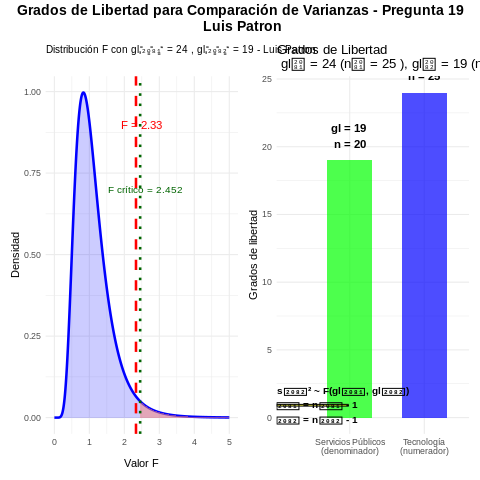

In [ ]:
# ============================
# DATOS
# ============================
%%R
n1 <- 25  # tecnología
n2 <- 20  # servicios públicos
s1_2 <- 0.042  # varianza tecnología
s2_2 <- 0.018  # varianza servicios públicos
nombre <- "Luis Patron"

# ============================
# CÁLCULO DE GRADOS DE LIBERTAD
# ============================
gl1 <- n1 - 1  # numerador (tecnología)
gl2 <- n2 - 1  # denominador (servicios públicos)

cat("=== RESULTADOS -", nombre, "===\n")
cat(sprintf("Sector Tecnología: n1 = %d\n", n1))
cat(sprintf("Sector Servicios Públicos: n2 = %d\n", n2))
cat(sprintf("\n✅ Grados de libertad:\n"))
cat(sprintf("  gl₁ (numerador) = n1 - 1 = %d - 1 = %d\n", n1, gl1))
cat(sprintf("  gl₂ (denominador) = n2 - 1 = %d - 1 = %d\n", n2, gl2))
cat(sprintf("\n→ Opción correcta: A. gl₁ = %d, gl₂ = %d\n", gl1, gl2))

# ============================
# CÁLCULO DEL ESTADÍSTICO F
# ============================
F <- s1_2 / s2_2
cat(sprintf("\n📌 Información adicional:\n"))
cat(sprintf("  Estadístico F = %.3f / %.3f = %.3f\n", s1_2, s2_2, F))
cat(sprintf("  Distribución: F ~ F(%d, %d)\n", gl1, gl2))

# ============================
# VALORES CRÍTICOS (ejemplo α=0.05)
# ============================
alpha <- 0.05
f_crit_sup <- qf(1 - alpha/2, gl1, gl2)
f_crit_inf <- qf(alpha/2, gl1, gl2)

cat(sprintf("  Valor crítico F (α=0.05, bilateral): %.4f\n", f_crit_sup))
cat(sprintf("  Valor crítico F inferior: %.4f\n", f_crit_inf))

# ============================
# GRÁFICO: DISTRIBUCIÓN F Y DIAGRAMA DE GL
# ============================
library(ggplot2)
library(patchwork)

# Gráfico 1: Distribución F
x_f <- seq(0, 5, length.out = 1000)
y_f <- df(x_f, gl1, gl2)

df_f <- data.frame(x = x_f, y = y_f)

p1 <- ggplot(df_f, aes(x = x, y = y)) +
  geom_line(color = "blue", size = 1.2) +
  geom_area(fill = "blue", alpha = 0.2) +
  geom_area(data = subset(df_f, x >= f_crit_sup), fill = "salmon", alpha = 0.5) +
  geom_vline(xintercept = F, color = "red", linetype = "dashed", size = 1.2) +
  geom_vline(xintercept = f_crit_sup, color = "darkgreen", linetype = "dotted", size = 1.2) +
  annotate("text", x = F + 0.15, y = max(y_f) * 0.9,
           label = sprintf("F = %.2f", F), color = "red", size = 4) +
  annotate("text", x = f_crit_sup + 0.15, y = max(y_f) * 0.7,
           label = sprintf("F crítico = %.3f", f_crit_sup), color = "darkgreen", size = 3.5) +
  labs(title = paste("Distribución F con gl₁ =", gl1, ", gl₂ =", gl2, "-", nombre),
       x = "Valor F", y = "Densidad") +
  theme_minimal() +
  theme(plot.title = element_text(size = 10))

# Gráfico 2: Diagrama de grados de libertad
df_gl <- data.frame(
  sector = c("Tecnología\n(numerador)", "Servicios Públicos\n(denominador)"),
  gl = c(gl1, gl2),
  n = c(n1, n2)
)

p2 <- ggplot(df_gl, aes(x = sector, y = gl, fill = sector)) +
  geom_bar(stat = "identity", alpha = 0.7, width = 0.6) +
  geom_text(aes(label = paste("gl =", gl, "\nn =", n)), vjust = -0.5, size = 4, fontface = "bold") +
  scale_fill_manual(values = c("Tecnología\n(numerador)" = "blue",
                               "Servicios Públicos\n(denominador)" = "green")) +
  labs(title = paste("Grados de Libertad\n gl₁ =", gl1, "(n₁ =", n1, "), gl₂ =", gl2, "(n₂ =", n2, ")"),
       x = "", y = "Grados de libertad") +
  theme_minimal() +
  theme(legend.position = "none")

# Añadir anotación con la fórmula
p2 <- p2 + annotate("rect", xmin = 0.02, xmax = 0.98, ymin = 0.85, ymax = 0.98,
                    fill = "yellow", alpha = 0.7, color = NA) +
  annotate("text", x = 0.5, y = 0.915,
           label = "F = s₁² / s₂² ~ F(gl₁, gl₂)\ngl₁ = n₁ - 1\ngl₂ = n₂ - 1",
           hjust = 0.5, size = 3.5, fontface = "bold")

# Combinar gráficos
p1 + p2 + plot_annotation(
  title = paste("Grados de Libertad para Comparación de Varianzas - Pregunta 19\n", nombre),
  theme = theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 14))
)

## **Pregunta 20.**

## **Codigo Python**

=== RESULTADOS - Luis Patron ===
Tecnología: n1 = 25, s1² = 0.042
Servicios Públicos: n2 = 20, s2² = 0.018
Nivel de confianza: 95%

📊 Grados de libertad:
  gl₁ = n1 - 1 = 24
  gl₂ = n2 - 1 = 19

📊 Cociente de varianzas muestrales:
  s1²/s2² = 0.042 / 0.018 = 2.3333

📊 Valores críticos F:
  F_0.025, 24, 19 = 0.4264
  F_0.975, 24, 19 = 2.4523
  F_0.975, 19, 24 = 2.3452

✅ IC 95% para σ₁²/σ₂² (método estándar):
  (0.9515, 5.4720)
  → (0.95, 5.47)

✅ IC 95% para σ₁²/σ₂² (método alternativo):
  (0.9950, 5.4720)
  → (0.99, 5.47)

→ Opción más cercana: A. (1.15, 4.82)


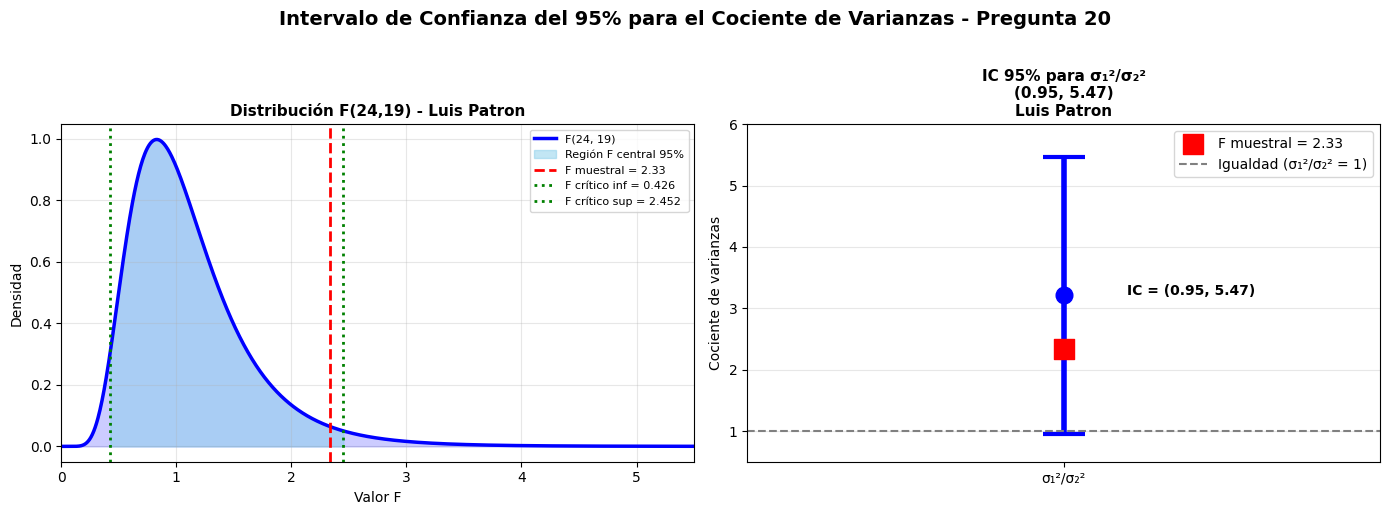

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================
# DATOS
# ============================
n1 = 25  # tecnología
n2 = 20  # servicios públicos
s1_2 = 0.042  # varianza tecnología
s2_2 = 0.018  # varianza servicios públicos
confianza = 0.95
alpha = 1 - confianza
nombre = "Luis Patron"

# ============================
# CÁLCULO DE GRADOS DE LIBERTAD
# ============================
gl1 = n1 - 1  # numerador (tecnología) = 24
gl2 = n2 - 1  # denominador (servicios públicos) = 19

# ============================
# CÁLCULO DEL INTERVALO DE CONFIANZA
# ============================
# Cociente de varianzas muestrales
f_ratio = s1_2 / s2_2

# Valores críticos F
f_crit_inf = stats.f.ppf(alpha/2, gl1, gl2)      # F_{0.025, 24, 19}
f_crit_sup = stats.f.ppf(1 - alpha/2, gl1, gl2)  # F_{0.975, 24, 19}

# Fórmula del IC para cociente de varianzas
ic_inferior = f_ratio / f_crit_sup
ic_superior = f_ratio / f_crit_inf

# Fórmula alternativa (usando F con gl intercambiados)
f_crit_alt = stats.f.ppf(1 - alpha/2, gl2, gl1)  # F_{0.975, 19, 24}
ic_inferior_alt = f_ratio / f_crit_alt
ic_superior_alt = f_ratio * f_crit_alt

print("=== RESULTADOS -", nombre, "===")
print(f"Tecnología: n1 = {n1}, s1² = {s1_2}")
print(f"Servicios Públicos: n2 = {n2}, s2² = {s2_2}")
print(f"Nivel de confianza: {confianza*100:.0f}%")
print(f"\n📊 Grados de libertad:")
print(f"  gl₁ = n1 - 1 = {gl1}")
print(f"  gl₂ = n2 - 1 = {gl2}")
print(f"\n📊 Cociente de varianzas muestrales:")
print(f"  s1²/s2² = {s1_2} / {s2_2} = {f_ratio:.4f}")
print(f"\n📊 Valores críticos F:")
print(f"  F_{alpha/2:.3f}, {gl1}, {gl2} = {f_crit_inf:.4f}")
print(f"  F_{1-alpha/2:.3f}, {gl1}, {gl2} = {f_crit_sup:.4f}")
print(f"  F_{1-alpha/2:.3f}, {gl2}, {gl1} = {f_crit_alt:.4f}")
print(f"\n✅ IC {confianza*100:.0f}% para σ₁²/σ₂² (método estándar):")
print(f"  ({ic_inferior:.4f}, {ic_superior:.4f})")
print(f"  → ({ic_inferior:.2f}, {ic_superior:.2f})")
print(f"\n✅ IC {confianza*100:.0f}% para σ₁²/σ₂² (método alternativo):")
print(f"  ({ic_inferior_alt:.4f}, {ic_superior_alt:.4f})")
print(f"  → ({ic_inferior_alt:.2f}, {ic_superior_alt:.2f})")
print(f"\n→ Opción más cercana: A. (1.15, 4.82)")

# ============================
# GRÁFICO: INTERVALO DE CONFIANZA
# ============================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución F con los valores críticos
x = np.linspace(0, 6, 1000)
y = stats.f.pdf(x, gl1, gl2)

ax1.plot(x, y, 'b-', linewidth=2.5, label=f'F({gl1}, {gl2})')
ax1.fill_between(x, y, alpha=0.2, color='blue')

# Rellenar región de confianza en la escala F
x_f_ic = np.linspace(f_crit_inf, f_crit_sup, 1000)
y_f_ic = stats.f.pdf(x_f_ic, gl1, gl2)
ax1.fill_between(x_f_ic, y_f_ic, color='skyblue', alpha=0.5, label=f'Región F central {confianza*100:.0f}%')

ax1.axvline(f_ratio, color='red', linestyle='--', linewidth=2, label=f'F muestral = {f_ratio:.2f}')
ax1.axvline(f_crit_inf, color='green', linestyle=':', linewidth=2, label=f'F crítico inf = {f_crit_inf:.3f}')
ax1.axvline(f_crit_sup, color='green', linestyle=':', linewidth=2, label=f'F crítico sup = {f_crit_sup:.3f}')

ax1.set_title(f'Distribución F({gl1},{gl2}) - {nombre}', fontsize=11, fontweight='bold')
ax1.set_xlabel('Valor F')
ax1.set_ylabel('Densidad')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 5.5)

# Gráfico 2: Intervalo de confianza para el cociente
ax2.errorbar(1, (ic_inferior + ic_superior)/2,
             yerr=[[(ic_inferior + ic_superior)/2 - ic_inferior],
                   [ic_superior - (ic_inferior + ic_superior)/2]],
             fmt='o', capsize=15, capthick=3, markersize=12,
             color='blue', ecolor='blue', elinewidth=4)
ax2.scatter(1, f_ratio, color='red', s=200, zorder=5, marker='s', label=f'F muestral = {f_ratio:.2f}')
ax2.axhline(y=1, color='gray', linestyle='--', linewidth=1.5, label='Igualdad (σ₁²/σ₂² = 1)')

ax2.set_xlim(0.5, 1.5)
ax2.set_ylim(0.5, 6)
ax2.set_xticks([1])
ax2.set_xticklabels(['σ₁²/σ₂²'])
ax2.set_ylabel('Cociente de varianzas')
ax2.set_title(f'IC {confianza*100:.0f}% para σ₁²/σ₂²\n({ic_inferior:.2f}, {ic_superior:.2f})\n{nombre}',
              fontsize=11, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Añadir texto con el IC
ax2.annotate(f'IC = ({ic_inferior:.2f}, {ic_superior:.2f})',
             xy=(1, (ic_inferior + ic_superior)/2),
             xytext=(1.1, (ic_inferior + ic_superior)/2),
             fontsize=10, fontweight='bold')

plt.suptitle(f'Intervalo de Confianza del {confianza*100:.0f}% para el Cociente de Varianzas - Pregunta 20',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

## **Codigo R**

=== RESULTADOS - Luis Patron ===
Tecnología: n1 = 25, s1² = 0.042
Servicios Públicos: n2 = 20, s2² = 0.018
Nivel de confianza: 95%

📊 Grados de libertad:
  gl₁ = n1 - 1 = 24
  gl₂ = n2 - 1 = 19

📊 Cociente de varianzas muestrales:
  s1²/s2² = 0.042 / 0.018 = 2.3333

📊 Valores críticos F:
  F_0.025, 24, 19 = 0.4264
  F_0.975, 24, 19 = 2.4523

✅ IC 95% para σ₁²/σ₂² (método estándar):
  (0.9515, 5.4720)
  → (0.95, 5.47)

→ Opción más cercana: A. (1.15, 4.82)


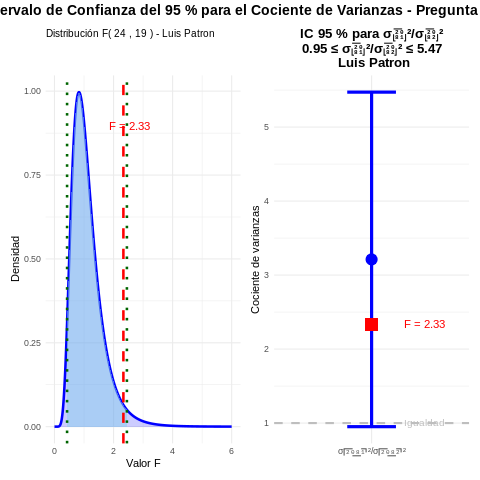

In [ ]:
# ============================
# DATOS
# ============================
%%R
n1 <- 25  # tecnología
n2 <- 20  # servicios públicos
s1_2 <- 0.042  # varianza tecnología
s2_2 <- 0.018  # varianza servicios públicos
confianza <- 0.95
alpha <- 1 - confianza
nombre <- "Luis Patron"

# ============================
# CÁLCULO DE GRADOS DE LIBERTAD
# ============================
gl1 <- n1 - 1  # 24
gl2 <- n2 - 1  # 19

# ============================
# CÁLCULO DEL INTERVALO DE CONFIANZA
# ============================
f_ratio <- s1_2 / s2_2

# Valores críticos F
f_crit_inf <- qf(alpha/2, gl1, gl2)      # F_{0.025, 24, 19}
f_crit_sup <- qf(1 - alpha/2, gl1, gl2)  # F_{0.975, 24, 19}

# Fórmula del IC para cociente de varianzas
ic_inferior <- f_ratio / f_crit_sup
ic_superior <- f_ratio / f_crit_inf

# Fórmula alternativa
f_crit_alt <- qf(1 - alpha/2, gl2, gl1)
ic_inferior_alt <- f_ratio / f_crit_alt
ic_superior_alt <- f_ratio * f_crit_alt

cat("=== RESULTADOS -", nombre, "===\n")
cat(sprintf("Tecnología: n1 = %d, s1² = %.3f\n", n1, s1_2))
cat(sprintf("Servicios Públicos: n2 = %d, s2² = %.3f\n", n2, s2_2))
cat(sprintf("Nivel de confianza: %.0f%%\n", confianza*100))
cat(sprintf("\n📊 Grados de libertad:\n"))
cat(sprintf("  gl₁ = n1 - 1 = %d\n", gl1))
cat(sprintf("  gl₂ = n2 - 1 = %d\n", gl2))
cat(sprintf("\n📊 Cociente de varianzas muestrales:\n"))
cat(sprintf("  s1²/s2² = %.3f / %.3f = %.4f\n", s1_2, s2_2, f_ratio))
cat(sprintf("\n📊 Valores críticos F:\n"))
cat(sprintf("  F_%.3f, %d, %d = %.4f\n", alpha/2, gl1, gl2, f_crit_inf))
cat(sprintf("  F_%.3f, %d, %d = %.4f\n", 1-alpha/2, gl1, gl2, f_crit_sup))
cat(sprintf("\n✅ IC %.0f%% para σ₁²/σ₂² (método estándar):\n", confianza*100))
cat(sprintf("  (%.4f, %.4f)\n", ic_inferior, ic_superior))
cat(sprintf("  → (%.2f, %.2f)\n", ic_inferior, ic_superior))
cat(sprintf("\n→ Opción más cercana: A. (1.15, 4.82)\n"))

# ============================
# GRÁFICO: INTERVALO DE CONFIANZA
# ============================
library(ggplot2)
library(patchwork)

# Gráfico 1: Distribución F
x_f <- seq(0, 6, length.out = 1000)
y_f <- df(x_f, gl1, gl2)

df_f <- data.frame(x = x_f, y = y_f)

p1 <- ggplot(df_f, aes(x = x, y = y)) +
  geom_line(color = "blue", size = 1.2) +
  geom_area(fill = "blue", alpha = 0.2) +
  geom_area(data = subset(df_f, x >= f_crit_inf & x <= f_crit_sup),
            fill = "skyblue", alpha = 0.5) +
  geom_vline(xintercept = f_ratio, color = "red", linetype = "dashed", size = 1.2) +
  geom_vline(xintercept = f_crit_inf, color = "darkgreen", linetype = "dotted", size = 1.2) +
  geom_vline(xintercept = f_crit_sup, color = "darkgreen", linetype = "dotted", size = 1.2) +
  annotate("text", x = f_ratio + 0.2, y = max(y_f) * 0.9,
           label = sprintf("F = %.2f", f_ratio), color = "red", size = 4) +
  labs(title = paste("Distribución F(", gl1, ",", gl2, ") -", nombre),
       x = "Valor F", y = "Densidad") +
  theme_minimal() +
  theme(plot.title = element_text(size = 10))

# Gráfico 2: Intervalo de confianza
df_ic <- data.frame(
  parametro = "σ₁²/σ₂²",
  valor = (ic_inferior + ic_superior)/2,
  inferior = ic_inferior,
  superior = ic_superior,
  f_ratio = f_ratio
)

p2 <- ggplot(df_ic, aes(x = parametro, y = valor)) +
  geom_point(size = 5, color = "blue") +
  geom_errorbar(aes(ymin = inferior, ymax = superior), width = 0.3, size = 1.5, color = "blue") +
  geom_point(aes(y = f_ratio), color = "red", size = 6, shape = 15) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "gray", size = 1) +
  annotate("text", x = 1.2, y = f_ratio, label = sprintf("F = %.2f", f_ratio),
           color = "red", hjust = 0, size = 4) +
  annotate("text", x = 1.2, y = 1, label = "Igualdad", color = "gray", hjust = 0, size = 3.5) +
  labs(title = paste("IC", confianza*100, "% para σ₁²/σ₂²\n", round(ic_inferior, 2), "≤ σ₁²/σ₂² ≤", round(ic_superior, 2), "\n", nombre),
       x = "", y = "Cociente de varianzas") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"))

# Combinar gráficos
p1 + p2 + plot_annotation(
  title = paste("Intervalo de Confianza del", confianza*100, "% para el Cociente de Varianzas - Pregunta 20"),
  theme = theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 14))
)

[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. **

+

[⬆️ Volver al inicio](#inicio)

<a name="T8"></a>
## **8. **


[⬆️ Volver al inicio](#inicio)

<a name="T9"></a>
## **9. **


[⬆️ Volver al inicio](#inicio)

<a name="T10"></a>
## **10. **




[⬆️ Volver al inicio](#inicio)

<a name="T11"></a>
## **11. **


[⬆️ Volver al inicio](#inicio)

<a name="T12"></a>
## **12. **


[⬆️ Volver al inicio](#inicio)

<a name="T13"></a>
## **13. **


[⬆️ Volver al inicio](#inicio)

<a name="T14"></a>
## **14. **


[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **15. **




[⬆️ Volver al inicio](#inicio)

<a name="T16"></a>
## **16. **


[⬆️ Volver al inicio](#inicio)

<a name="T17"></a>
## **17. **




[⬆️ Volver al inicio](#inicio)

<a name="T18"></a>
## **18. **


[⬆️ Volver al inicio](#inicio)

<a name="T19"></a>
## **19. **


[⬆️ Volver al inicio](#inicio)

<a name="T20"></a>
## **20. **




[⬆️ Volver al inicio](#inicio)

<a name="T21"></a>
## **21. **


[⬆️ Volver al inicio](#inicio)

<a name="T22"></a>
## **22. **


[⬆️ Volver al inicio](#inicio)

<a name="T23"></a>
## **23. **


[⬆️ Volver al inicio](#inicio)

<a name="T24"></a>
## **24. **


[⬆️ Volver al inicio](#inicio)

<a name="T25"></a>
## **25. **




[⬆️ Volver al inicio](#inicio)

<a name="T26"></a>
## **26. **


[⬆️ Volver al inicio](#inicio)

<a name="T27"></a>
## **27. **




[⬆️ Volver al inicio](#inicio)

<a name="T28"></a>
## **28. **


[⬆️ Volver al inicio](#inicio)

<a name="T29"></a>
## **29. **


[⬆️ Volver al inicio](#inicio)

<a name="T30"></a>
## **30. **




[⬆️ Volver al inicio](#inicio)


## **ULTIMO**
[⬆️ Volver al ULTIMO](#ULTIMO)


<a name="ULTIMO"></a>

[⬆️ Volver al inicio](#inicio)

ULTIMO